# Imports

In [4]:
import os
import utils
import settings
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt

# Single trial analysis

## Initiate trial

In [2]:
subjectPath = os.path.join(utils.SIMULATIONS_DIR, utils.SUBJECTS_TO_ANALYSE[0])
sessionPath = os.path.join(subjectPath, utils.SESSIONS_TO_ANALYSE[0])
trialPath = os.path.join(sessionPath, utils.TRIALS_TO_ANALYSE[0])
# trialPath = r'C:\Git\1_current_projects\powerlifing_model\simulations\Athlete_03\25_03_31\Walking_02'
print(f'Analyzing trial at path: {trialPath}')

analysis = utils.Analyse(trialPath)
# analysis.reset_settings_xml()
# print main inputs
print("Main inputs:")
print(f"Model file: {analysis.model_dir}")
print(f"time range: {analysis.time_range}")
print(f"IK file: {analysis.ik}")



Analyzing trial at path: c:\Git\1_current_projects\powerlifing_model\simulations\Athlete_03_MRI_BG\25_03_31\Squat_bw_01
Settings loaded from: c:\Git\1_current_projects\powerlifing_model\simulations\Athlete_03_MRI_BG\25_03_31\Squat_bw_01\trial_settings.xml
Main inputs:
Model file: ..\..\..\..\models\Athlete_03_MRI_BG\25_03_31\scaled.osim
time range: [0.005, 3.535]
IK file: joint_angles.mot


## Export C3D

In [ ]:
analysis.export_c3d()

## Optimise model (modonese)

In [ ]:
import muscleOptimizer

muscleOptimizer.main(osim_model_targ_filepath=analysis.model_dir,
                     osim_model_ref_filepath=os.path.join(utils.MODELS_DIR, 'Catelli-V4.0_PowerliftingMarkers.osim'))

## Run IK

In [ ]:
analysis.replace = True
analysis.run_ik()
analysis.plot_ik()


## run id

In [ ]:
analysis.run_id()
analysis.plot_id()

## run ma

In [ ]:
analysis.run_ma()
analysis.plot_moment_arms()

## run so

In [ ]:
analysis.replace = True
analysis.run_so()

## run jra

In [ ]:
analysis.run_jra()

## emg normalise / scale / plot

In [ ]:
analysis.run_emg_normalise()
analysis.scale_emg(scale_factor=0.70)
# analysis.plot_emg()

## Create ceinms setup files

In [ ]:
analysis.replace = False

analysis.create_ceinms_model()

analysis.create_ceinms_input_data()

analysis.create_ceinms_calibration_cfg()

analysis.create_ceinms_calibration_setup()

analysis.create_excitation_generator()

analysis.create_ceinms_exe_cfg()

analysis.create_ceinms_exe_setup()

## ceinms calibration

In [ ]:
analysis.run_ceinms_calibration()

## run ceinms exe

In [ ]:
analysis.run_ceinms_exe()

In [ ]:
analysis.run_jra_ceinms()

## JRA ceinms 

In [ ]:
analysis.replace = True
analysis.run_jra_ceinms()

## push to git

In [ ]:
analysis.push_trial_results_to_git()

# Batch from settings

In [ ]:

for folder, subfolder, files in os.walk(utils.SIMULATIONS_DIR):
    if not os.path.basename(folder) in utils.TRIALS_TO_ANALYSE:
        continue
    print(f'Analyzing trial at path: {folder}')
    
    analysis = utils.Analyse(folder)
    
    analysis.run_ik()
    analysis.run_id()
    analysis.run_ma()
    analysis.run_so()
    analysis.run_jra()
    analysis.run_emg_normalise()
    analysis.scale_emg(scale_factor=0.70)
    analysis.create_ceinms_input_data()
    analysis.create_ceinms_exe_setup()
    analysis.create_ceinms_exe_cfg()
    analysis.run_ceinms_exe_loop()
    analysis.push_trial_results_to_git()
    
    
    
    

# Plots

## IK

Settings loaded from: c:\Git\1_current_projects\powerlifing_model\simulations\Athlete_03\25_03_31\Squat_bw_01\trial_settings.xml
Settings loaded from: c:\Git\1_current_projects\powerlifing_model\simulations\Athlete_03_MRI_BG\25_03_31\Squat_bw_01\trial_settings.xml
IK comparison plot saved: c:\Git\1_current_projects\powerlifing_model\results\Compare_models\ik_Squat_bw_01.png


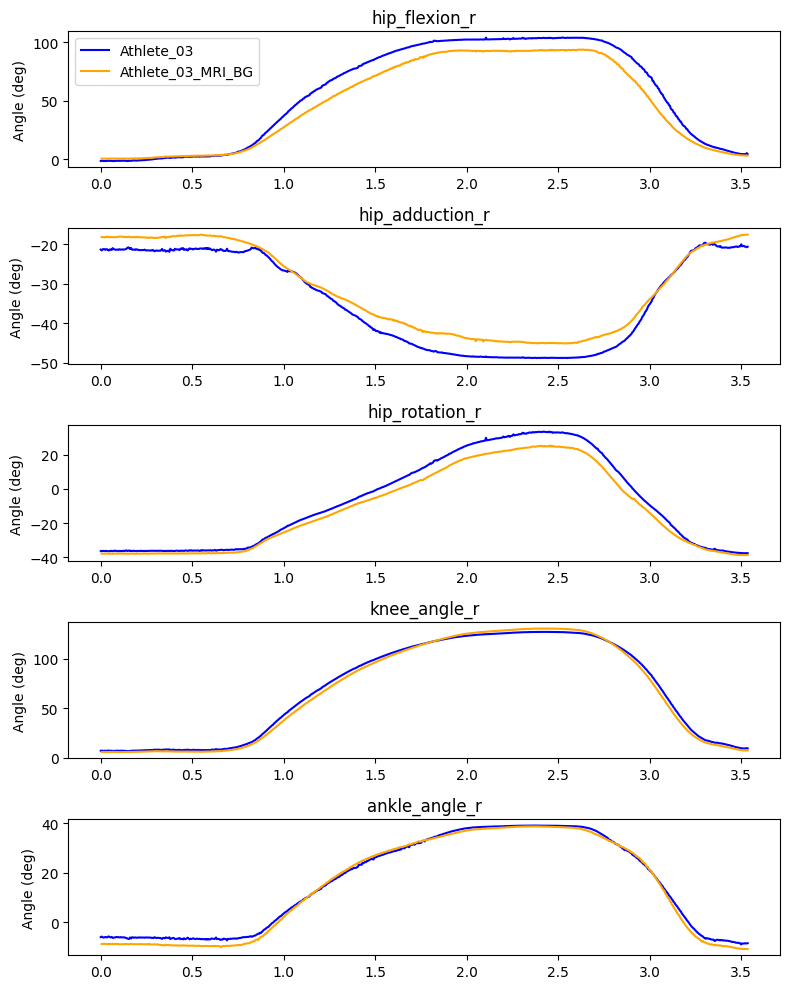

In [18]:
import matplotlib.pyplot as plt
import opensim as osim
ik_columns = ['hip_flexion_r', 'hip_adduction_r', 'hip_rotation_r', 'knee_angle_r', 'ankle_angle_r']
id_columns = ['hip_flexion_r_moment', 'hip_adduction_r_moment', 'hip_rotation_r_moment', 'knee_angle_r_moment', 'ankle_angle_r_moment']

results_dir = os.path.join(utils.RESULTS_DIR, 'Compare_models')

os.makedirs(results_dir, exist_ok=True)

trialName = 'Walking_02'
trialName = 'Squat_bw_01'

colors = {'scaled': 'blue',
          'MRI_BG': 'orange'}

trialPath_scaled = os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03', '25_03_31', trialName)
trial_scaled = utils.Analyse(trialPath_scaled)

trialPath_MRI = os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03_MRI_BG', '25_03_31', trialName)
trial_MRI = utils.Analyse(trialPath_MRI)

model = osim.Model(trial_scaled.model_dir)
state = model.initSystem()
bodyMass = model.getTotalMass(state)

# compare IK results
ik_scaled = utils.load_any_data_file(os.path.join(trial_scaled.path, trial_scaled.ik))
ik_MRI = utils.load_any_data_file(os.path.join(trial_MRI.path, trial_MRI.ik))

fig, ax = plt.subplots(5,   1, figsize=(8, 10))
for col in ik_columns:
    ax_idx = ik_columns.index(col)
    ax[ax_idx].plot(ik_scaled['time'], ik_scaled[col], label=trial_scaled.subject, color=colors['scaled'])
    ax[ax_idx].plot(ik_MRI['time'], ik_MRI[col], label=trial_MRI.subject, color=colors['MRI_BG'])
    ax[ax_idx].set_title(col)   
    ax[ax_idx].set_ylabel('Angle (deg)')
    if ax_idx == 0:
        ax[ax_idx].legend()
plt.tight_layout()
save_path = os.path.join(results_dir, f'ik_{trialName}.png')
plt.savefig(save_path)
print(f"IK comparison plot saved: {save_path}")
    




## ID

ID comparison plot saved: c:\Git\1_current_projects\powerlifing_model\results\Compare_models\id_Squat_bw_01.png


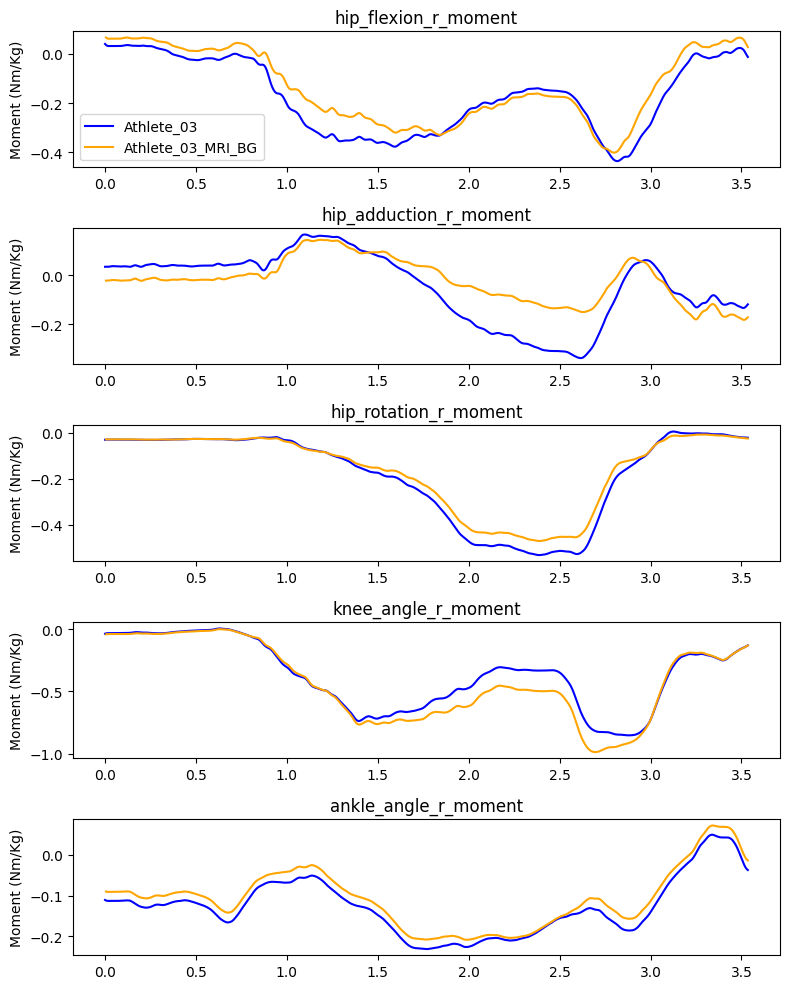

In [9]:
# plot ID results
id_scaled = utils.load_any_data_file(os.path.join(trial_scaled.path, trial_scaled.id))
id_MRI = utils.load_any_data_file(os.path.join(trial_MRI.path, trial_MRI.id))

fig, ax = plt.subplots(len(id_columns),   1, figsize=(8, 10))
for col in id_columns:
    ax_idx = id_columns.index(col)
    ax[ax_idx].plot(id_scaled['time'], id_scaled[col]/bodyMass, label=trial_scaled.subject, color=colors['scaled'])
    ax[ax_idx].plot(id_MRI['time'], id_MRI[col]/bodyMass, label=trial_MRI.subject, color=colors['MRI_BG'])
    ax[ax_idx].set_title(col)   
    ax[ax_idx].set_ylabel('Moment (Nm/Kg)')
    if ax_idx == 0:
        ax[ax_idx].legend()
plt.tight_layout()
save_path = os.path.join(results_dir, f'id_{trialName}.png')
plt.savefig(save_path)
print(f"ID comparison plot saved: {save_path}")

## Plot Moment arms

MA comparison plot saved: c:\Git\1_current_projects\powerlifing_model\results\Compare_models\ma_hip_flexion_r.png
MA comparison plot saved: c:\Git\1_current_projects\powerlifing_model\results\Compare_models\ma_hip_adduction_r.png
MA comparison plot saved: c:\Git\1_current_projects\powerlifing_model\results\Compare_models\ma_hip_rotation_r.png
MA comparison plot saved: c:\Git\1_current_projects\powerlifing_model\results\Compare_models\ma_knee_angle_r.png
MA comparison plot saved: c:\Git\1_current_projects\powerlifing_model\results\Compare_models\ma_ankle_angle_r.png


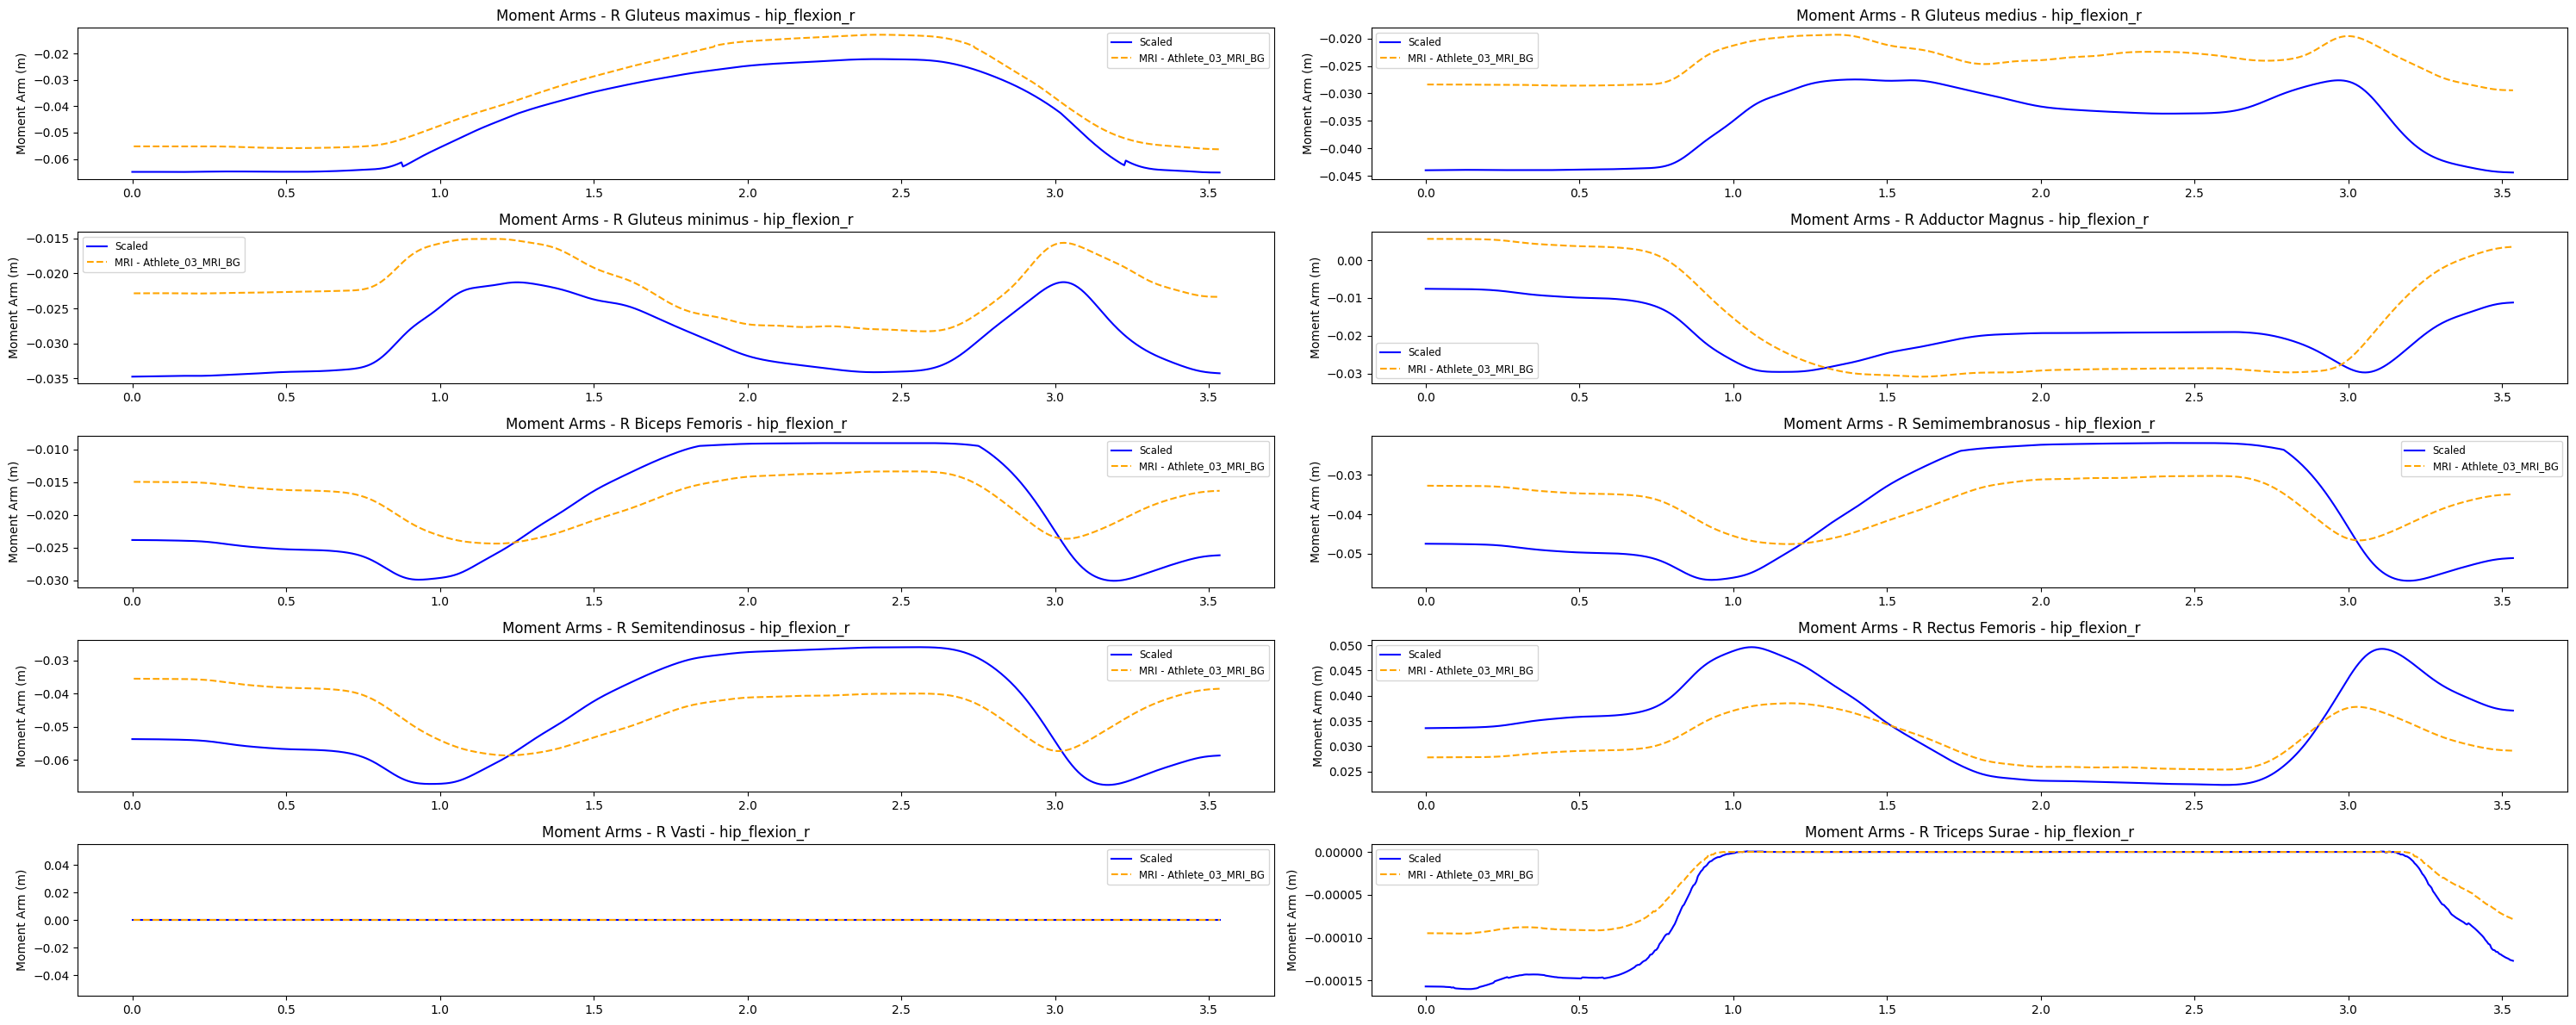

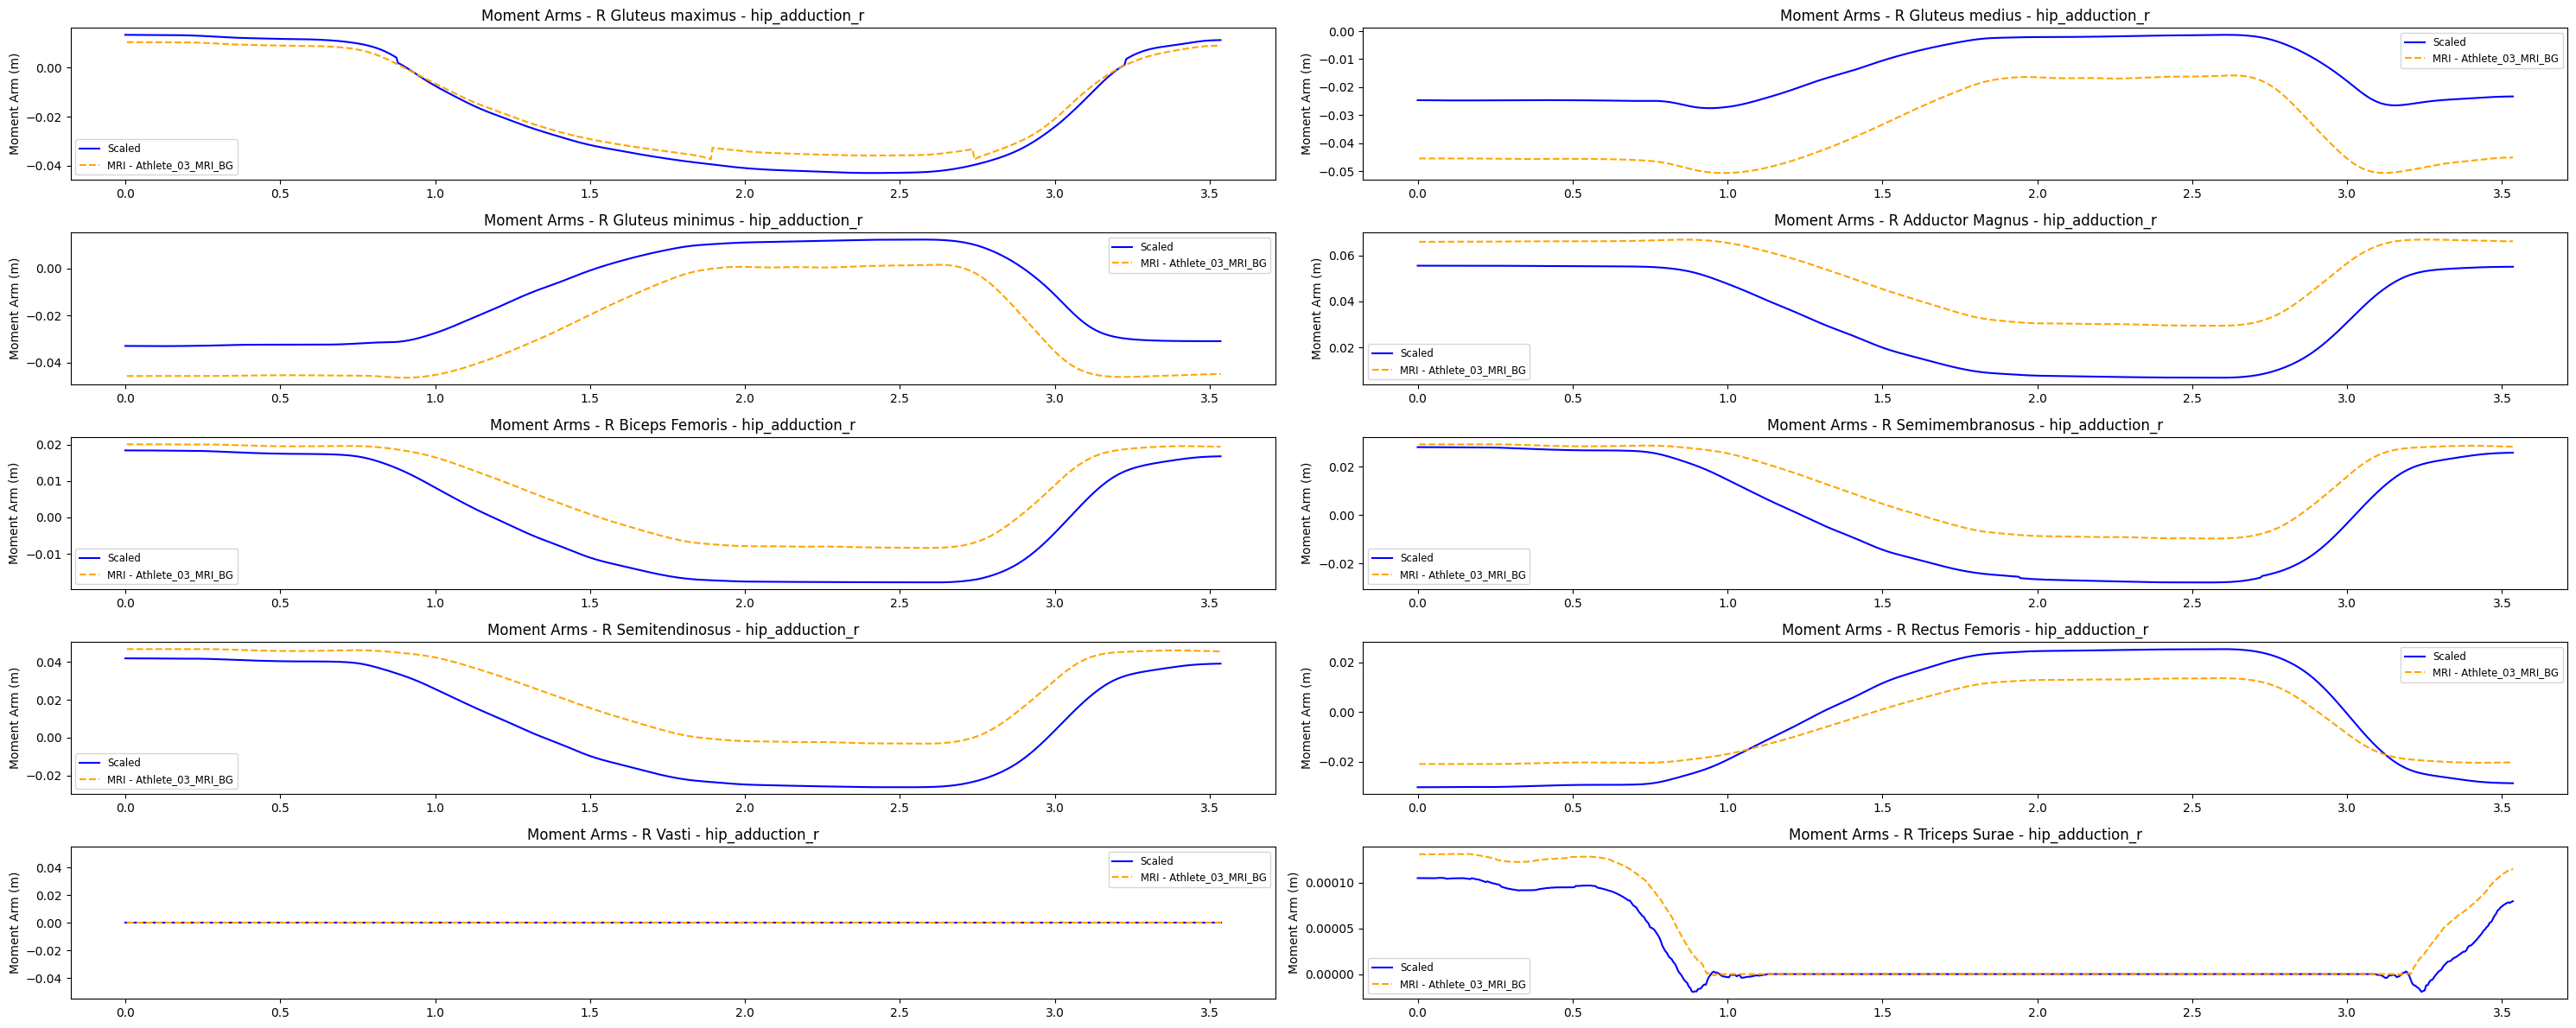

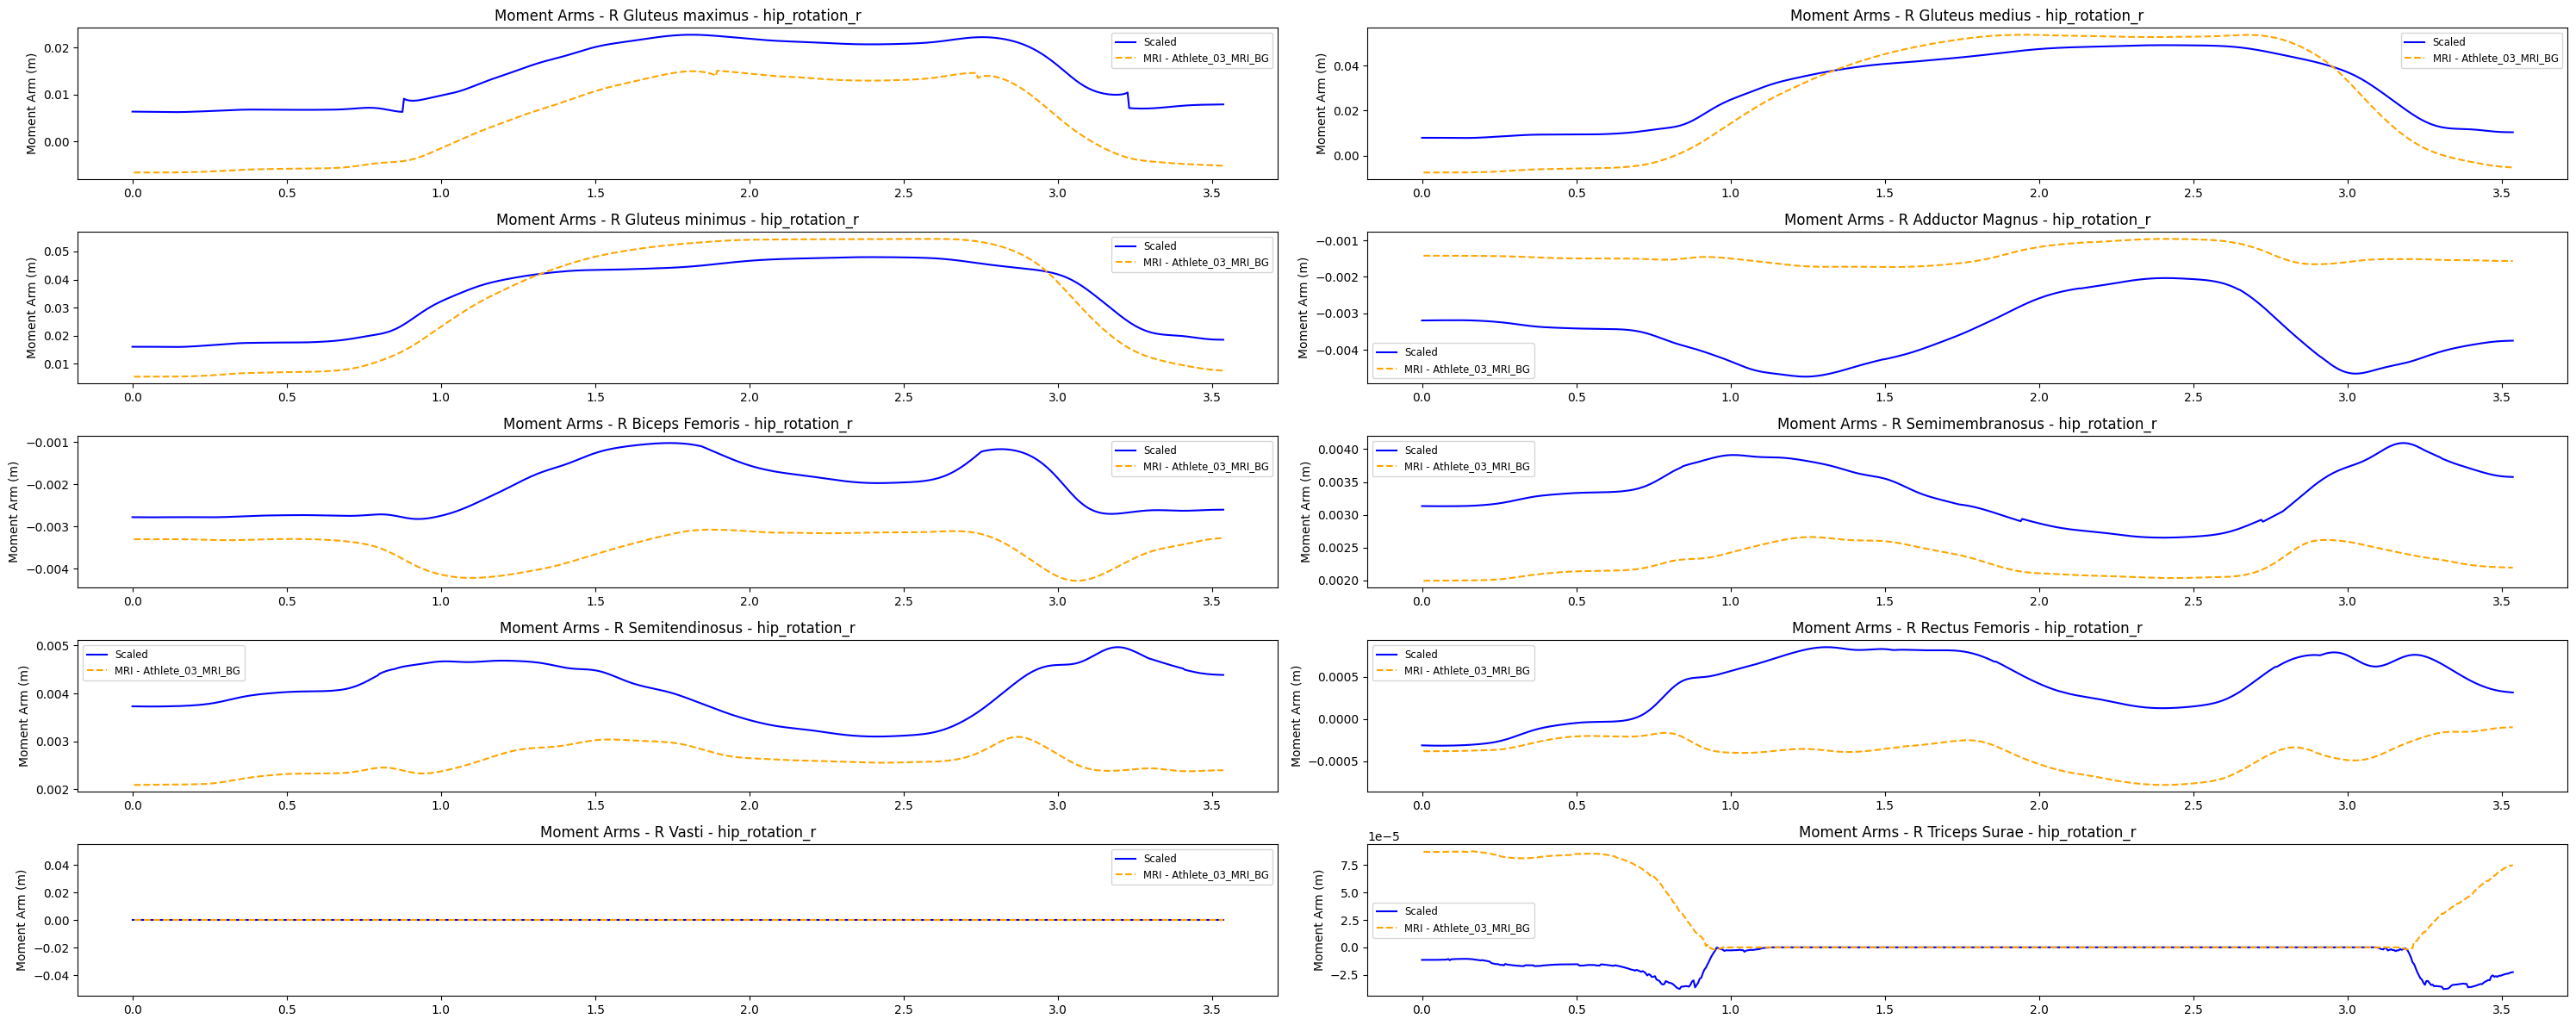

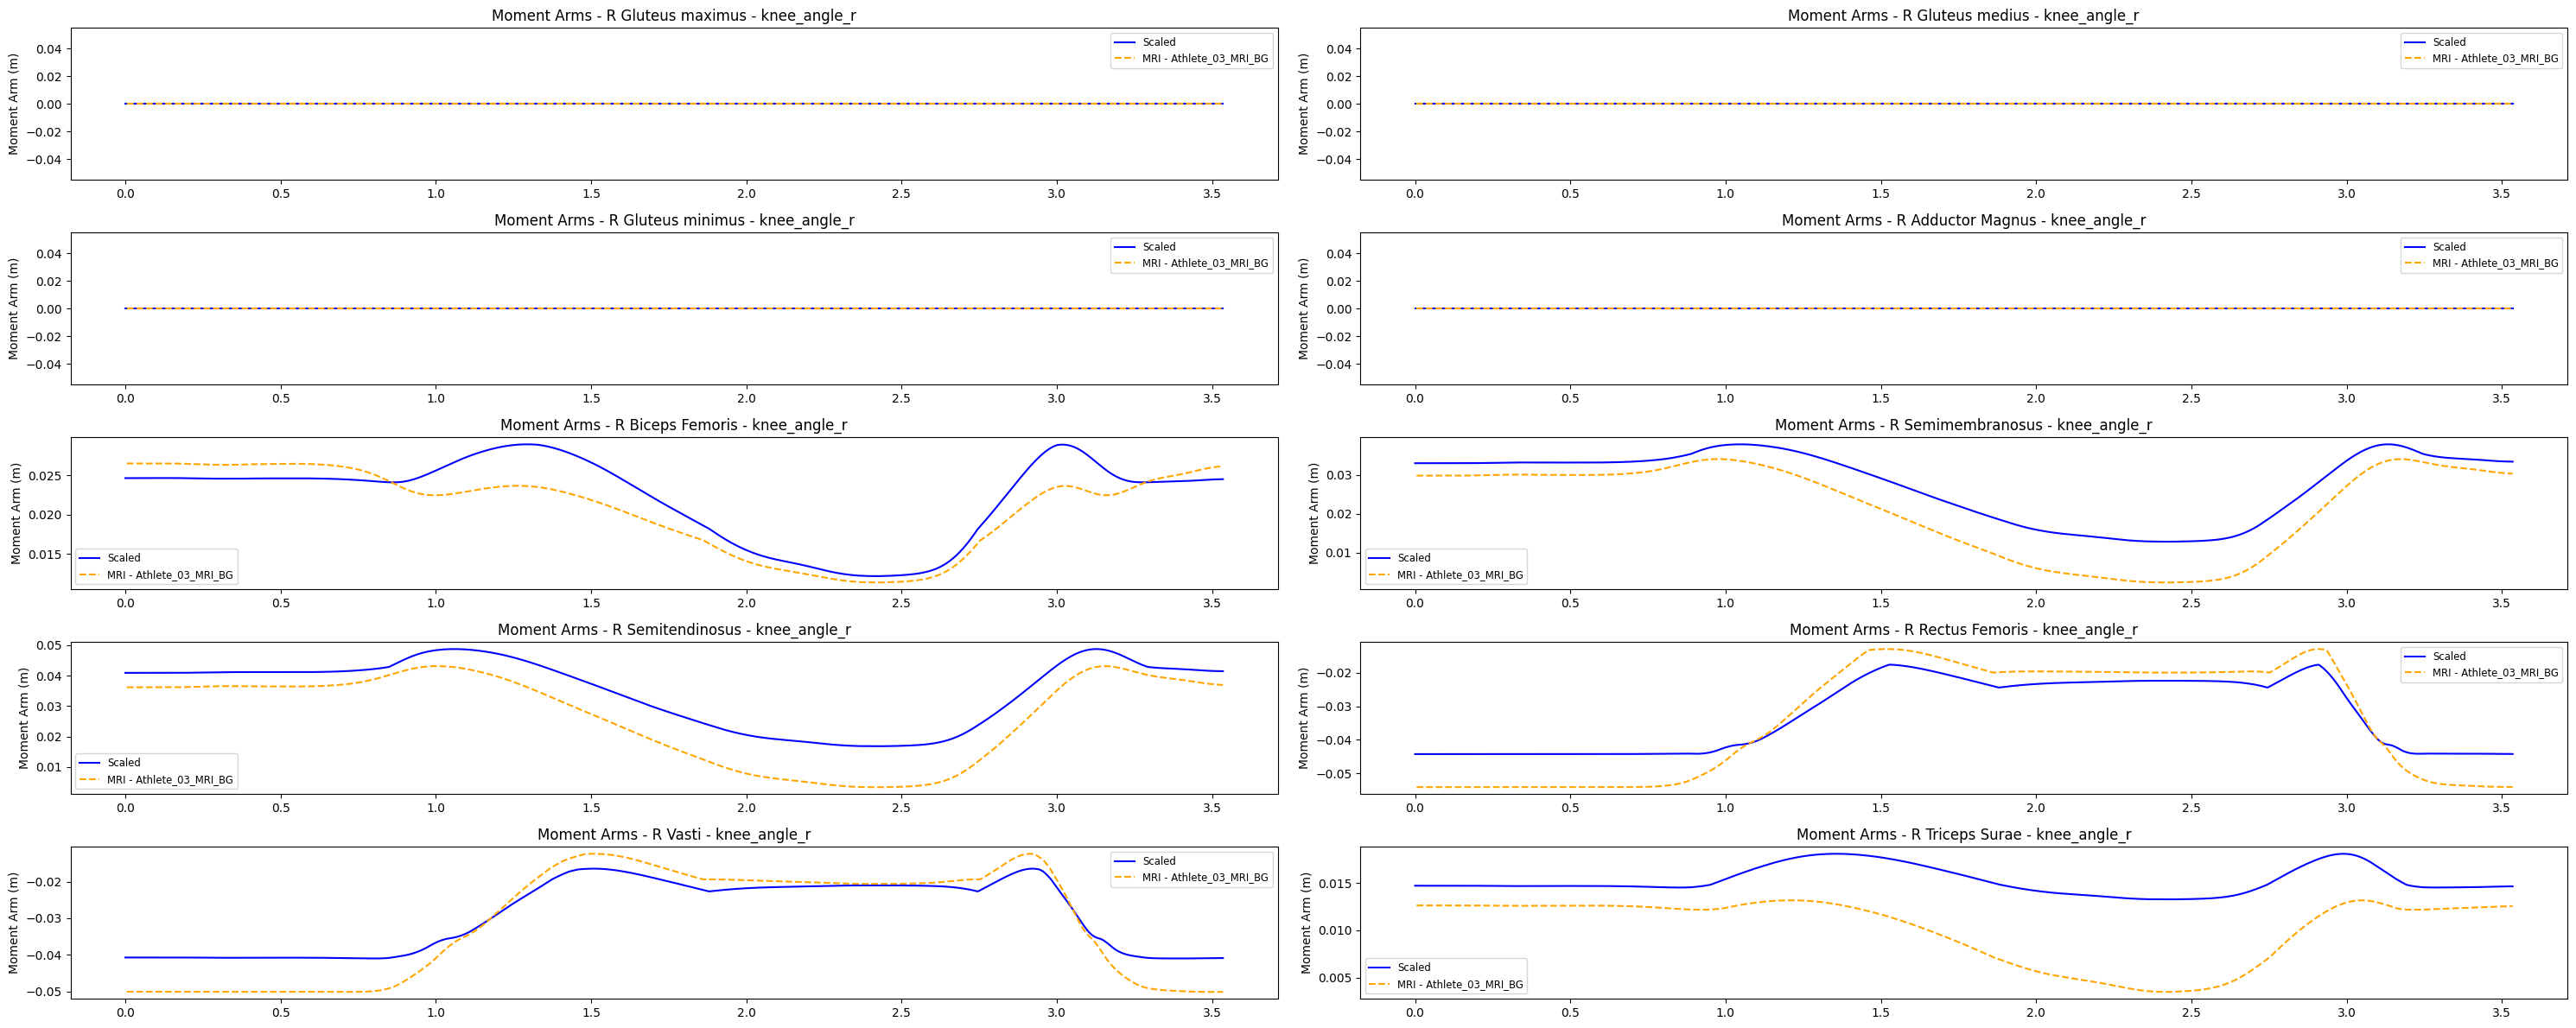

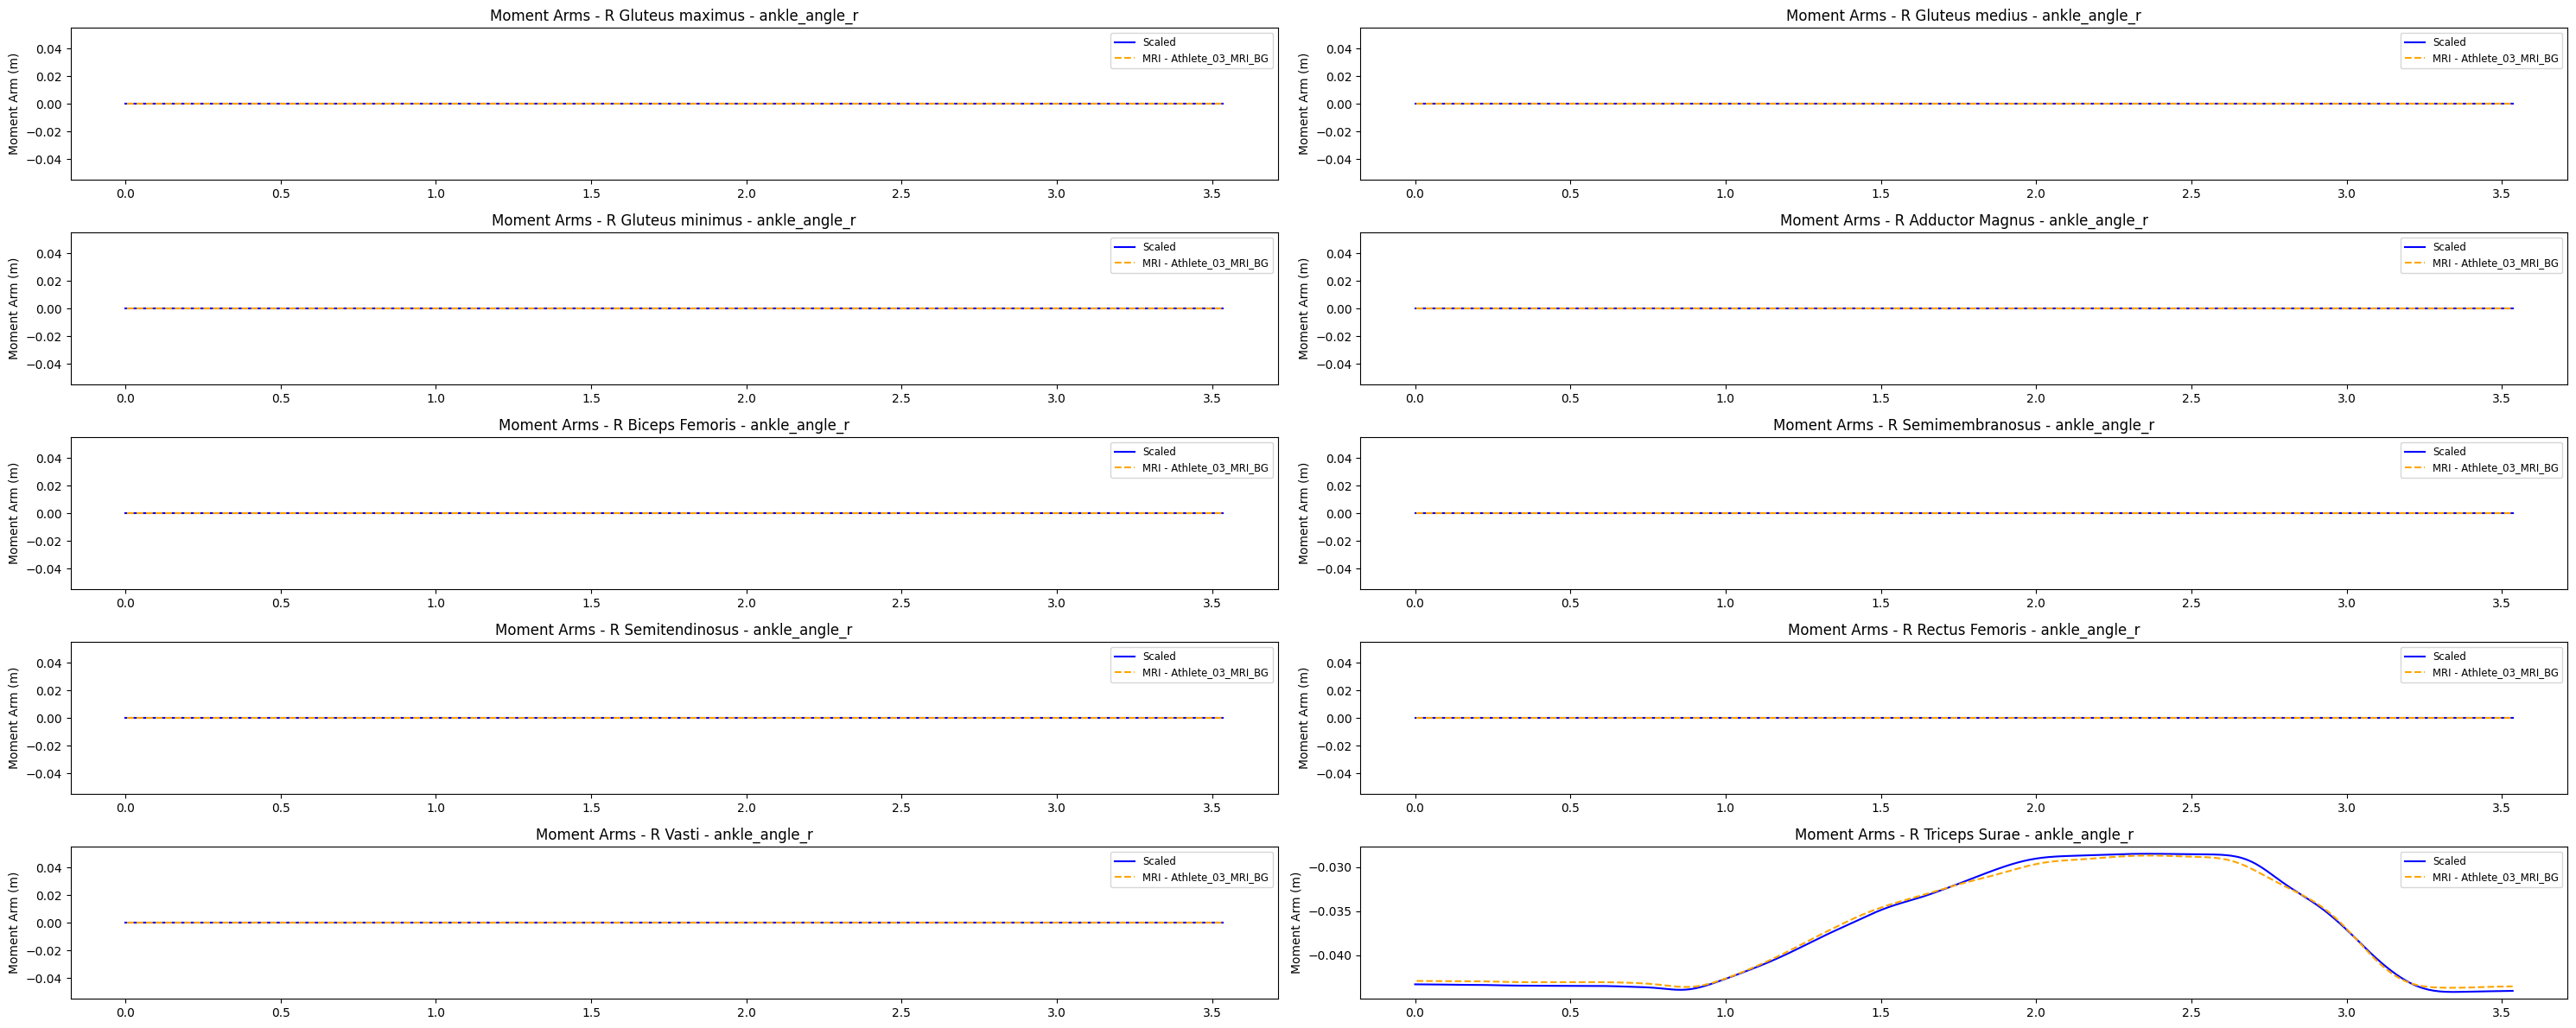

In [15]:

for dof in ik_columns:
    scale_results = utils.load_any_data_file(os.path.join(trial_scaled.path, trial_scaled.ma, f'_MuscleAnalysis_MomentArm_{dof}.sto'))
    mri_results = utils.load_any_data_file(os.path.join(trial_MRI.path, trial_MRI.ma, f'_MuscleAnalysis_MomentArm_{dof}.sto'))
    
    muscleGroups = settings.Muscle_Groups
    
    fig, ax = plt.subplots(5,2,figsize=(30, 12))
    
    for count, (muscleGroup, muscles) in enumerate(muscleGroups.items()):
        ax_row = count // 2
        ax_col = count % 2

        ax[ax_row, ax_col].plot(scale_results['time'], scale_results[muscles].mean(axis=1), label=f'Scaled', color= colors['scaled'])
        ax[ax_row, ax_col].plot(mri_results['time'], mri_results[muscles].mean(axis=1), label=f'MRI - {trial_MRI.subject}', linestyle='--', color= colors['MRI_BG'])
        ax[ax_row, ax_col].set_title(f'Moment Arms - {muscleGroup} - {dof}')
        ax[ax_row, ax_col].set_ylabel('Moment Arm (m)')
        ax[ax_row, ax_col].legend(fontsize='small')
        
        if count > len(muscleGroups)-1:
            ax[ax_row, ax_col].xticklabels([])


    plt.tight_layout()
    save_path = os.path.join(results_dir, f'ma_{dof}.png')
    plt.savefig(save_path)
    print(f"MA comparison plot saved: {save_path}")

In [13]:
scale_results[muscle]


0     -0.057041
1     -0.057040
2     -0.057038
3     -0.057036
4     -0.057035
         ...   
703   -0.055960
704   -0.055971
705   -0.055981
706   -0.055989
707   -0.055997
Name: glmax1_r, Length: 708, dtype: float64

## Norm Fibre lengths

In [ ]:
ceinms_folder = os.path.join(trial_scaled.path, trial_scaled.jra_forces_ceinms.split('\\')[0])
ceinms_scaled = utils.load_any_data_file(os.path.join(ceinms_folder, 'NormFibreLengths.sto'))

ceinms_folder = os.path.join(trial_MRI.path, trial_MRI.jra_forces_ceinms.split('\\')[0])
ceinms_MRI = utils.load_any_data_file(os.path.join(ceinms_folder, 'NormFibreLengths.sto'))

muscleGroups = settings.Muscle_Groups

n_rows = np.round(len(muscleGroups)/5)
n_cols = 5
fig, ax = plt.subplots(nrows=int(n_rows), ncols=int(n_cols), figsize=(15, 8))

labels = ['scaled CEINMS', 'MRI CEINMS']
ax = ax.flatten()
for count, (muscleGroup, muscles) in enumerate(muscleGroups.items()):
    
    print(f'Plotting muscle forces for: {muscles}')
    
    # CEINMS scaled
    ax[count].plot(ceinms_scaled['time'], ceinms_scaled[muscles].mean(axis=1), label=labels[0], color=colors['scaled'])
    ax[count].set_title(f'{muscles} - Scaled SO')

    # MRI CEINMS
    ax[count].plot(ceinms_MRI['time'], ceinms_MRI[muscles].mean(axis=1), label=labels[1], color=colors['MRI_BG'], linestyle='--')
    ax[count].set_title(f'{muscleGroup}')
    
    if count == 0:
        handles, labels = ax[count].get_legend_handles_labels()
        handles = [handles[0], handles[1]]
        labels = [labels[0], labels[1]]
        ax[count].legend(handles, labels)
        
    if count == len(muscleGroups)-1:
        ax[count].set_xlabel('Time (s)')
        
plt.tight_layout()
save_path = os.path.join(results_dir, f'norm_fibre_lengths_{trialName}.png')
plt.savefig(save_path)
print(f"Norm Fibre Lengths comparison plot saved: {save_path}")


## Plot Muscle forces

In [ ]:

mf_scaled_so = utils.load_any_data_file(os.path.join(trial_scaled.path, trial_scaled.so_forces))
mf_scaled_CEINMS = utils.load_any_data_file(os.path.join(trial_scaled.path, trial_scaled.jra_forces_ceinms))
mf_MRI_so = utils.load_any_data_file(os.path.join(trial_MRI.path, trial_MRI.so_forces))
mf_MRI_CEINMS = utils.load_any_data_file(os.path.join(trial_MRI.path, trial_MRI.jra_forces_ceinms))

muscleGroups = settings.Muscle_Groups

n_rows = np.round(len(muscleGroups)/5)
n_cols = 5
fig, ax = plt.subplots(nrows=int(n_rows), ncols=int(n_cols), figsize=(15, 8))

labels = ['Scaled SO', 'Scaled CEINMS', 'MRI SO', 'MRI CEINMS']
ax = ax.flatten()
for count, (muscleGroup, muscles) in enumerate(muscleGroups.items()):
    
    print(f'Plotting muscle forces for: {muscles}')
    # SO scaled
    sum_forces = mf_scaled_so[muscles].sum(axis=1)
    ax[count].plot(mf_scaled_so['time'], sum_forces, label=labels[0], color=colors['scaled'])
    ax[count].set_title(f'{muscles} - Scaled SO')

    # CEINMS scaled
    sum_forces = mf_scaled_CEINMS[muscles].sum(axis=1)
    ax[count].plot(mf_scaled_CEINMS['time'], sum_forces, label=labels[1], color=colors['scaled'], linestyle='--')
    
    # MRI so
    sum_forces = mf_MRI_so[muscles].sum(axis=1)
    ax[count].plot(mf_MRI_so['time'], sum_forces, label=labels[2], color=colors['MRI_BG'])
    
    # MRI CEINMS
    ax[count].plot(mf_MRI_CEINMS['time'], mf_MRI_CEINMS[muscles].sum(axis=1), label=labels[3], color=colors['MRI_BG'], linestyle='--')
    ax[count].set_title(f'{muscleGroup}')
    
    if count == 0:
        ax[count].legend()
        
    if count == len(muscleGroups)-1:
        ax[count].set_xlabel('Time (s)')
plt.tight_layout()
save_path = os.path.join(results_dir, f'muscle_forces_{trialName}.png')
plt.savefig(save_path)
print(f"Muscle forces comparison plot saved: {save_path}")

## Plot JRA

In [ ]:
import numpy as np
    

jra_so = utils.load_any_data_file(os.path.join(trial_scaled.path, trial_scaled.jra))
jra_ceinms = utils.load_any_data_file(os.path.join(trial_scaled.path, trial_scaled.jra_ceinms))

jra_mri_so = utils.load_any_data_file(os.path.join(trial_MRI.path, trial_MRI.jra))
jra_mri_ceinms = utils.load_any_data_file(os.path.join(trial_MRI.path, trial_MRI.jra_ceinms))

fig, ax = plt.subplots(3,   4, figsize=(15, 8))

labels = ['scaled SO', 'scaled CEINMS', 'MRI SO', 'MRI CEINMS']
count = -1
for df in [jra_so, jra_ceinms, jra_mri_so, jra_mri_ceinms]:
    count += 1
    
    if count == 0 or count == 2:
        color = colors['scaled']
    else:
        color = colors['MRI_BG']
    # plot Hip first row    
    x = df['hip_r_on_femur_r_in_femur_r_fx']
    y = df['hip_r_on_femur_r_in_femur_r_fy']
    z = df['hip_r_on_femur_r_in_femur_r_fz']
    sum = np.linalg.norm([x,y,z], axis=0)
    ax[0, 0].plot(df['time'], x, label=labels[count], color=color)
    ax[0, 1].plot(df['time'], y, label=labels[count], color=color)
    ax[0, 2].plot(df['time'], z, label=labels[count], color=color)
    ax[0, 3].plot(df['time'], sum, label=labels[count], color=color)
    
    ax[0, 0].set_title('Hip Forces _X')
    ax[0, 1].set_title('Hip Forces _Y')
    ax[0, 2].set_title('Hip Forces _Z')
    ax[0, 3].set_title('Hip Forces _sum')
    
    # plot Hip first row
    x = df['walker_knee_r_on_tibia_r_in_tibia_r_fx']
    y = df['walker_knee_r_on_tibia_r_in_tibia_r_fy']
    z = df['walker_knee_r_on_tibia_r_in_tibia_r_fz']
    sum = np.linalg.norm([x,y,z], axis=0)
    ax[1, 0].plot(df['time'], x, label=labels[count]+' _X', color=color)
    ax[1, 1].plot(df['time'], y, label=labels[count]+' _Y', color=color)
    ax[1, 2].plot(df['time'], z, label=labels[count]+' _Z', color=color)
    ax[1, 3].plot(df['time'], sum, label=labels[count]+' _sum', color=color)
    
    # plot Ankle last row
    x = df['ankle_r_on_talus_r_in_talus_r_fx']
    y = df['ankle_r_on_talus_r_in_talus_r_fy']
    z = df['ankle_r_on_talus_r_in_talus_r_fz']
    sum = np.linalg.norm([x,y,z], axis=0)
    ax[2, 0].plot(df['time'], x, label=labels[count]+' _X', color=color)
    ax[2, 1].plot(df['time'], y, label=labels[count]+' _Y', color=color)
    ax[2, 2].plot(df['time'], z, label=labels[count]+' _Z', color=color)
    ax[2, 3].plot(df['time'], sum, label=labels[count]+' _sum', color=color)
    
    if count == len([jra_so, jra_ceinms, jra_mri_so, jra_mri_ceinms])-1:
        ax[2, 0].set_xlabel('Time (s)')
        ax[2, 1].set_xlabel('Time (s)')
        ax[2, 2].set_xlabel('Time (s)')
        ax[2, 3].set_xlabel('Time (s)')
    else:
        # remove x labels for other rows
        for i in range(4):
            ax[0, i].set_xticklabels([])
            ax[1, i].set_xticklabels([])
            
        
        

ax[0, 0].legend()
plt.tight_layout()
save_path = os.path.join(results_dir, f'jra_{trialName}.png')
plt.savefig(save_path)
print(f"JRA comparison plot saved: {save_path}")
    

## Summary plot

In [ ]:



walking_scaled_results_results.load_settings(walking_scaled.settingsXML)

AttributeError: 'Analyse' object has no attribute 'settingsXML'

# Plot 3 tasks

In [32]:

trialName = 'Walking_02'
walking_scaled = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03', '25_03_31', trialName))
walking_MRI = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03_MRI_BG', '25_03_31', trialName))

squat_trial = 'Squat_bw_01'
squat_scaled = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03', '25_03_31', squat_trial))
squat_MRI = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03_MRI_BG', '25_03_31', squat_trial))

weighted_squat_tiral = 'Squat_35kg_01'
weighted_squat_scaled = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03', '25_03_31', weighted_squat_tiral))
weighted_squat_MRI = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03_MRI_BG', '25_03_31', weighted_squat_tiral))




Settings loaded from: c:\Git\1_current_projects\powerlifing_model\simulations\Athlete_03\25_03_31\Walking_02\trial_settings.xml
Settings loaded from: c:\Git\1_current_projects\powerlifing_model\simulations\Athlete_03_MRI_BG\25_03_31\Walking_02\trial_settings.xml
Settings loaded from: c:\Git\1_current_projects\powerlifing_model\simulations\Athlete_03\25_03_31\Squat_bw_01\trial_settings.xml
Settings loaded from: c:\Git\1_current_projects\powerlifing_model\simulations\Athlete_03_MRI_BG\25_03_31\Squat_bw_01\trial_settings.xml
Settings loaded from: c:\Git\1_current_projects\powerlifing_model\simulations\Athlete_03\25_03_31\Squat_35kg_01\trial_settings.xml
Settings loaded from: c:\Git\1_current_projects\powerlifing_model\simulations\Athlete_03_MRI_BG\25_03_31\Squat_35kg_01\trial_settings.xml


## IK

IK comparison plot saved: c:\Git\1_current_projects\powerlifing_model\results\Compare_models\ik_comparison_all_trials.png


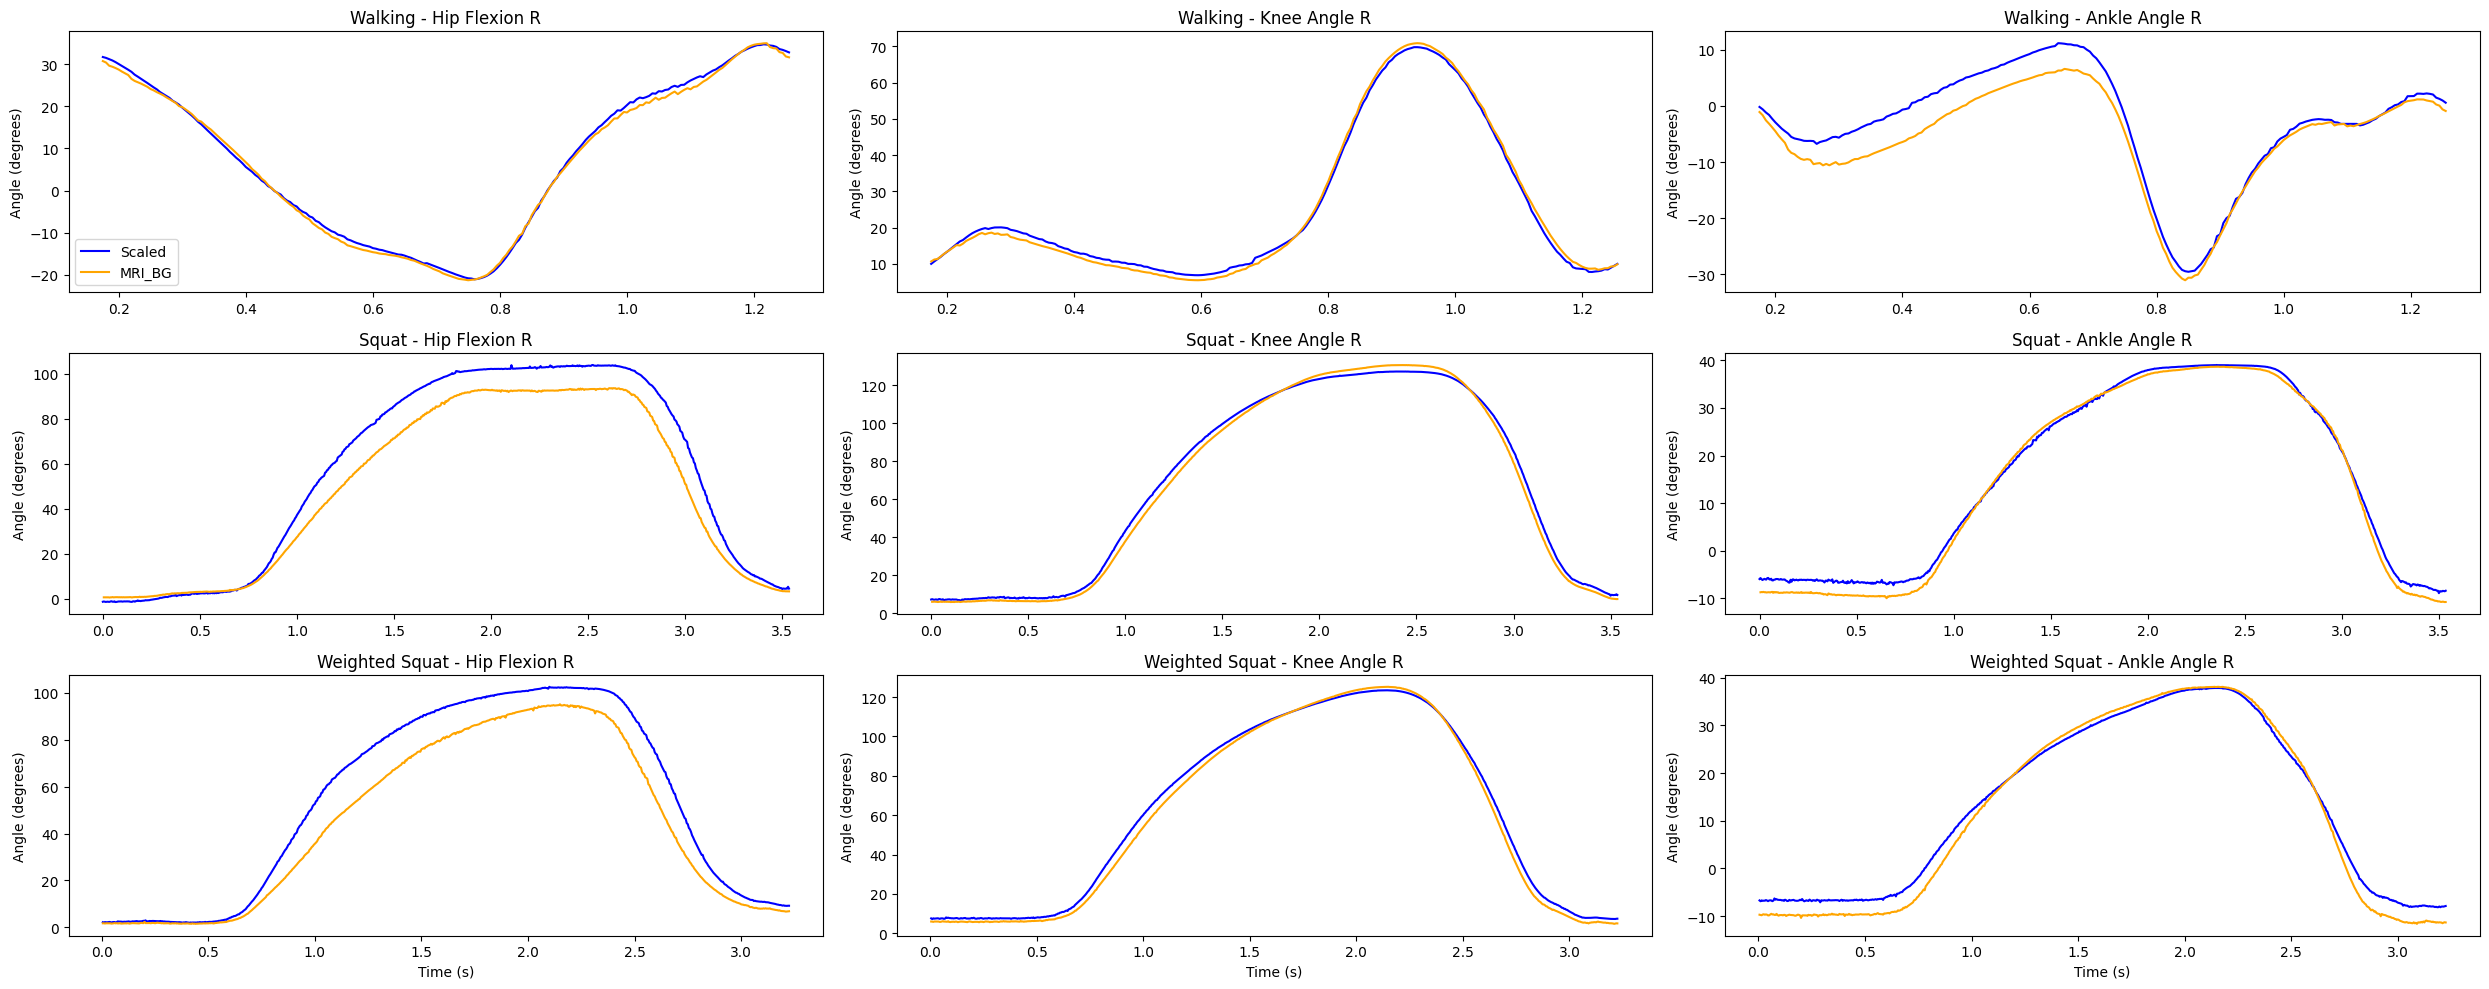

In [33]:

fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(25, 10))

walking_scaled_results = utils.load_any_data_file(os.path.join(walking_scaled.path, walking_scaled.ik))
walking_MRI_results = utils.load_any_data_file(os.path.join(walking_MRI.path, walking_MRI.ik))

squat_scaled_results = utils.load_any_data_file(os.path.join(squat_scaled.path, squat_scaled.ik))
squat_MRI_results = utils.load_any_data_file(os.path.join(squat_MRI.path, squat_MRI.ik)) 

weighted_squat_scaled_results = utils.load_any_data_file(os.path.join(weighted_squat_scaled.path, weighted_squat_scaled.ik))
weighted_squat_MRI_results = utils.load_any_data_file(os.path.join(weighted_squat_MRI.path, weighted_squat_MRI.ik))

# walking row
ax[0, 0].plot(walking_scaled_results['time'], walking_scaled_results['hip_flexion_r'], label='Scaled', color=colors['scaled'])
ax[0, 0].plot(walking_MRI_results['time'], walking_MRI_results['hip_flexion_r'], label='MRI_BG', color=colors['MRI_BG'])  
ax[0, 0].set_title('Walking - Hip Flexion R')
ax[0, 0].legend()
ax[0, 0].set_ylabel('Angle (degrees)')

ax[0, 1].plot(walking_scaled_results['time'], walking_scaled_results['knee_angle_r'], label='Scaled', color=colors['scaled'])
ax[0, 1].plot(walking_MRI_results['time'], walking_MRI_results['knee_angle_r'], label='MRI_BG', color=colors['MRI_BG'])
ax[0, 1].set_title('Walking - Knee Angle R')
ax[0, 1].set_ylabel('Angle (degrees)')
ax[0, 2].plot(walking_scaled_results['time'], walking_scaled_results['ankle_angle_r'], label='Scaled', color=colors['scaled'])
ax[0, 2].plot(walking_MRI_results['time'], walking_MRI_results['ankle_angle_r'], label='MRI_BG', color=colors['MRI_BG'])
ax[0, 2].set_title('Walking - Ankle Angle R')
ax[0, 2].set_ylabel('Angle (degrees)')

# squat row
ax[1, 0].plot(squat_scaled_results['time'], squat_scaled_results['hip_flexion_r'], label='Scaled', color=colors['scaled'])
ax[1, 0].plot(squat_MRI_results['time'], squat_MRI_results['hip_flexion_r'], label='MRI_BG', color=colors['MRI_BG'])
ax[1, 0].set_title('Squat - Hip Flexion R')
ax[1, 0].set_ylabel('Angle (degrees)')

ax[1, 1].plot(squat_scaled_results['time'], squat_scaled_results['knee_angle_r'], label='Scaled', color=colors['scaled'])
ax[1, 1].plot(squat_MRI_results['time'], squat_MRI_results['knee_angle_r'], label='MRI_BG', color=colors['MRI_BG'])
ax[1, 1].set_title('Squat - Knee Angle R')
ax[1, 1].set_ylabel('Angle (degrees)')

ax[1, 2].plot(squat_scaled_results['time'], squat_scaled_results['ankle_angle_r'], label='Scaled', color=colors['scaled'])
ax[1, 2].plot(squat_MRI_results['time'], squat_MRI_results['ankle_angle_r'], label='MRI_BG', color=colors['MRI_BG'])
ax[1, 2].set_title('Squat - Ankle Angle R')
ax[1, 2].set_ylabel('Angle (degrees)')

# weighted squat row
ax[2, 0].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results['hip_flexion_r'], label='Scaled', color=colors['scaled'])
ax[2, 0].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results['hip_flexion_r'], label='MRI_BG', color=colors['MRI_BG'])
ax[2, 0].set_title('Weighted Squat - Hip Flexion R')    
ax[2, 0].set_ylabel('Angle (degrees)')
ax[2, 0].set_xlabel('Time (s)') 

ax[2, 1].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results['knee_angle_r'], label='Scaled', color=colors['scaled'])
ax[2, 1].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results['knee_angle_r'], label='MRI_BG', color=colors['MRI_BG'])
ax[2, 1].set_title('Weighted Squat - Knee Angle R')
ax[2, 1].set_ylabel('Angle (degrees)')
ax[2, 1].set_xlabel('Time (s)') 

ax[2, 2].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results['ankle_angle_r'], label='Scaled', color=colors['scaled'])
ax[2, 2].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results['ankle_angle_r'], label='MRI_BG', color=colors['MRI_BG'])
ax[2, 2].set_title('Weighted Squat - Ankle Angle R')
ax[2, 2].set_ylabel('Angle (degrees)')
ax[2, 2].set_xlabel('Time (s)') 

save_path = os.path.join(results_dir, f'ik_comparison_all_trials.png')
plt.tight_layout()

plt.savefig(save_path)
print(f"IK comparison plot saved: {save_path}")





## ID 

ID comparison plot saved: c:\Git\1_current_projects\powerlifing_model\results\Compare_models\id_comparison_all_trials.png


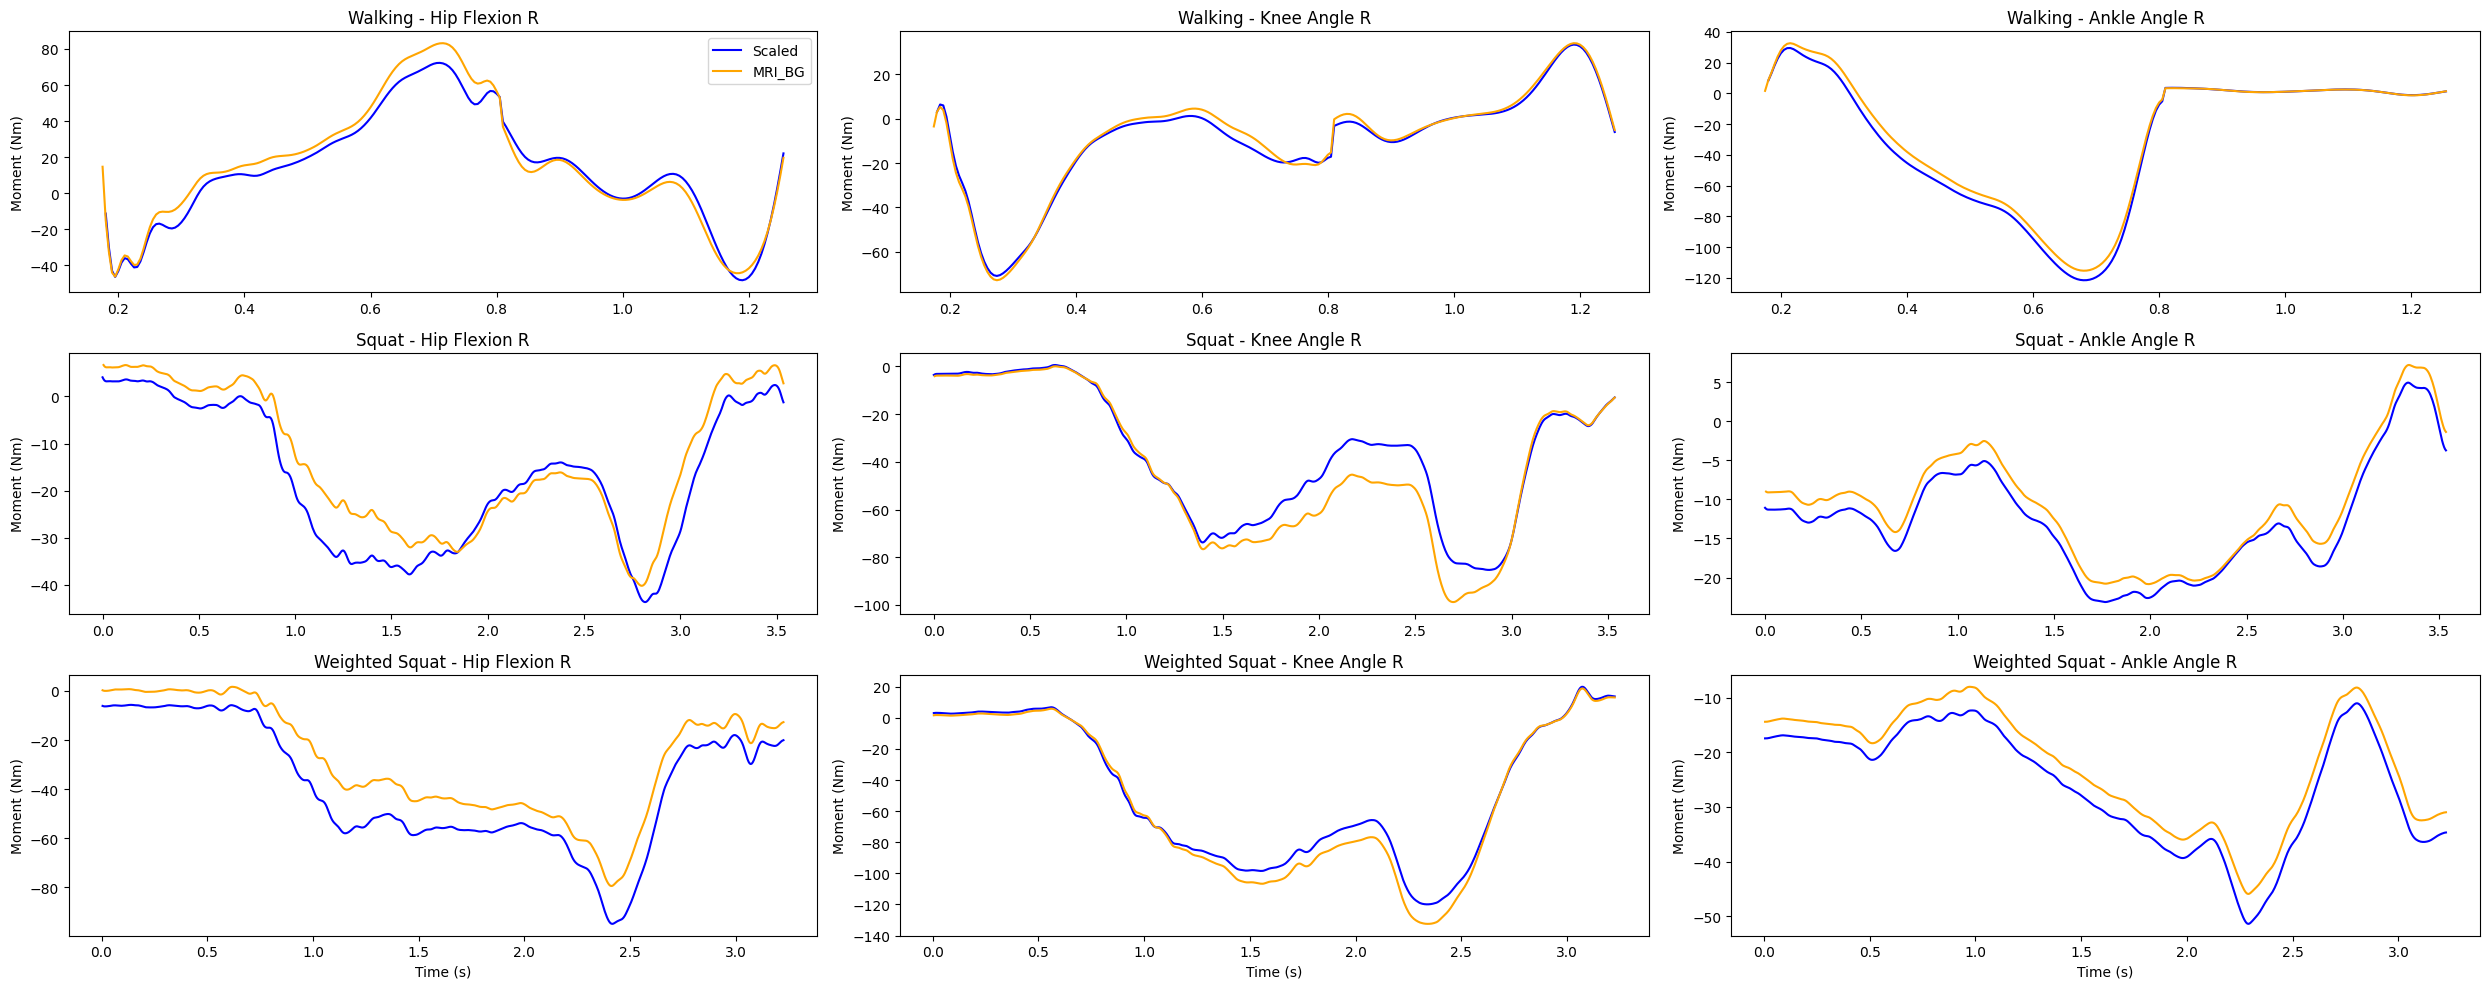

In [34]:

fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(25, 10))

walking_scaled_results = utils.load_any_data_file(os.path.join(walking_scaled.path, walking_scaled.id))
walking_MRI_results = utils.load_any_data_file(os.path.join(walking_MRI.path, walking_MRI.id))

squat_scaled_results = utils.load_any_data_file(os.path.join(squat_scaled.path, squat_scaled.id))
squat_MRI_results = utils.load_any_data_file(os.path.join(squat_MRI.path, squat_MRI.id)) 

weighted_squat_scaled_results = utils.load_any_data_file(os.path.join(weighted_squat_scaled.path, weighted_squat_scaled.id))
weighted_squat_MRI_results = utils.load_any_data_file(os.path.join(weighted_squat_MRI.path, weighted_squat_MRI.id))

# walking row
ax[0, 0].plot(walking_scaled_results['time'], walking_scaled_results['hip_flexion_r_moment'], label='Scaled', color=colors['scaled'])
ax[0, 0].plot(walking_MRI_results['time'], walking_MRI_results['hip_flexion_r_moment'], label='MRI_BG', color=colors['MRI_BG'])  
ax[0, 0].set_title('Walking - Hip Flexion R')
ax[0, 0].legend()
ax[0, 0].set_ylabel('Moment (Nm)')

ax[0, 1].plot(walking_scaled_results['time'], walking_scaled_results['knee_angle_r_moment'], label='Scaled', color=colors['scaled'])
ax[0, 1].plot(walking_MRI_results['time'], walking_MRI_results['knee_angle_r_moment'], label='MRI_BG', color=colors['MRI_BG'])
ax[0, 1].set_title('Walking - Knee Angle R')
ax[0, 1].set_ylabel('Moment (Nm)')

ax[0, 2].plot(walking_scaled_results['time'], walking_scaled_results['ankle_angle_r_moment'], label='Scaled', color=colors['scaled'])
ax[0, 2].plot(walking_MRI_results['time'], walking_MRI_results['ankle_angle_r_moment'], label='MRI_BG', color=colors['MRI_BG'])
ax[0, 2].set_title('Walking - Ankle Angle R')
ax[0, 2].set_ylabel('Moment (Nm)')

# squat row
ax[1, 0].plot(squat_scaled_results['time'], squat_scaled_results['hip_flexion_r_moment'], label='Scaled', color=colors['scaled'])
ax[1, 0].plot(squat_MRI_results['time'], squat_MRI_results['hip_flexion_r_moment'], label='MRI_BG', color=colors['MRI_BG'])
ax[1, 0].set_title('Squat - Hip Flexion R')
ax[1, 0].set_ylabel('Moment (Nm)')

ax[1, 1].plot(squat_scaled_results['time'], squat_scaled_results['knee_angle_r_moment'], label='Scaled', color=colors['scaled'])
ax[1, 1].plot(squat_MRI_results['time'], squat_MRI_results['knee_angle_r_moment'], label='MRI_BG', color=colors['MRI_BG'])
ax[1, 1].set_title('Squat - Knee Angle R')
ax[1, 1].set_ylabel('Moment (Nm)')

ax[1, 2].plot(squat_scaled_results['time'], squat_scaled_results['ankle_angle_r_moment'], label='Scaled', color=colors['scaled'])
ax[1, 2].plot(squat_MRI_results['time'], squat_MRI_results['ankle_angle_r_moment'], label='MRI_BG', color=colors['MRI_BG'])
ax[1, 2].set_title('Squat - Ankle Angle R')
ax[1, 2].set_ylabel('Moment (Nm)')

# weighted squat row
ax[2, 0].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results['hip_flexion_r_moment'], label='Scaled', color=colors['scaled'])
ax[2, 0].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results['hip_flexion_r_moment'], label='MRI_BG', color=colors['MRI_BG'])
ax[2, 0].set_title('Weighted Squat - Hip Flexion R')
ax[2, 0].set_ylabel('Moment (Nm)')
ax[2, 0].set_xlabel('Time (s)')

ax[2, 1].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results['knee_angle_r_moment'], label='Scaled', color=colors['scaled'])
ax[2, 1].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results['knee_angle_r_moment'], label='MRI_BG', color=colors['MRI_BG'])
ax[2, 1].set_title('Weighted Squat - Knee Angle R')
ax[2, 1].set_ylabel('Moment (Nm)')
ax[2, 1].set_xlabel('Time (s)')

ax[2, 2].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results['ankle_angle_r_moment'], label='Scaled', color=colors['scaled'])
ax[2, 2].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results['ankle_angle_r_moment'], label='MRI_BG', color=colors['MRI_BG'])
ax[2, 2].set_title('Weighted Squat - Ankle Angle R')
ax[2, 2].set_ylabel('Moment (Nm)')
ax[2, 2].set_xlabel('Time (s)')


save_path = os.path.join(results_dir, f'id_comparison_all_trials.png')
plt.tight_layout()

plt.savefig(save_path)
print(f"ID comparison plot saved: {save_path}")




## Moment arms

MA comparison plot saved: c:\Git\1_current_projects\powerlifing_model\results\Compare_models\ma_comparison_all_trials.png


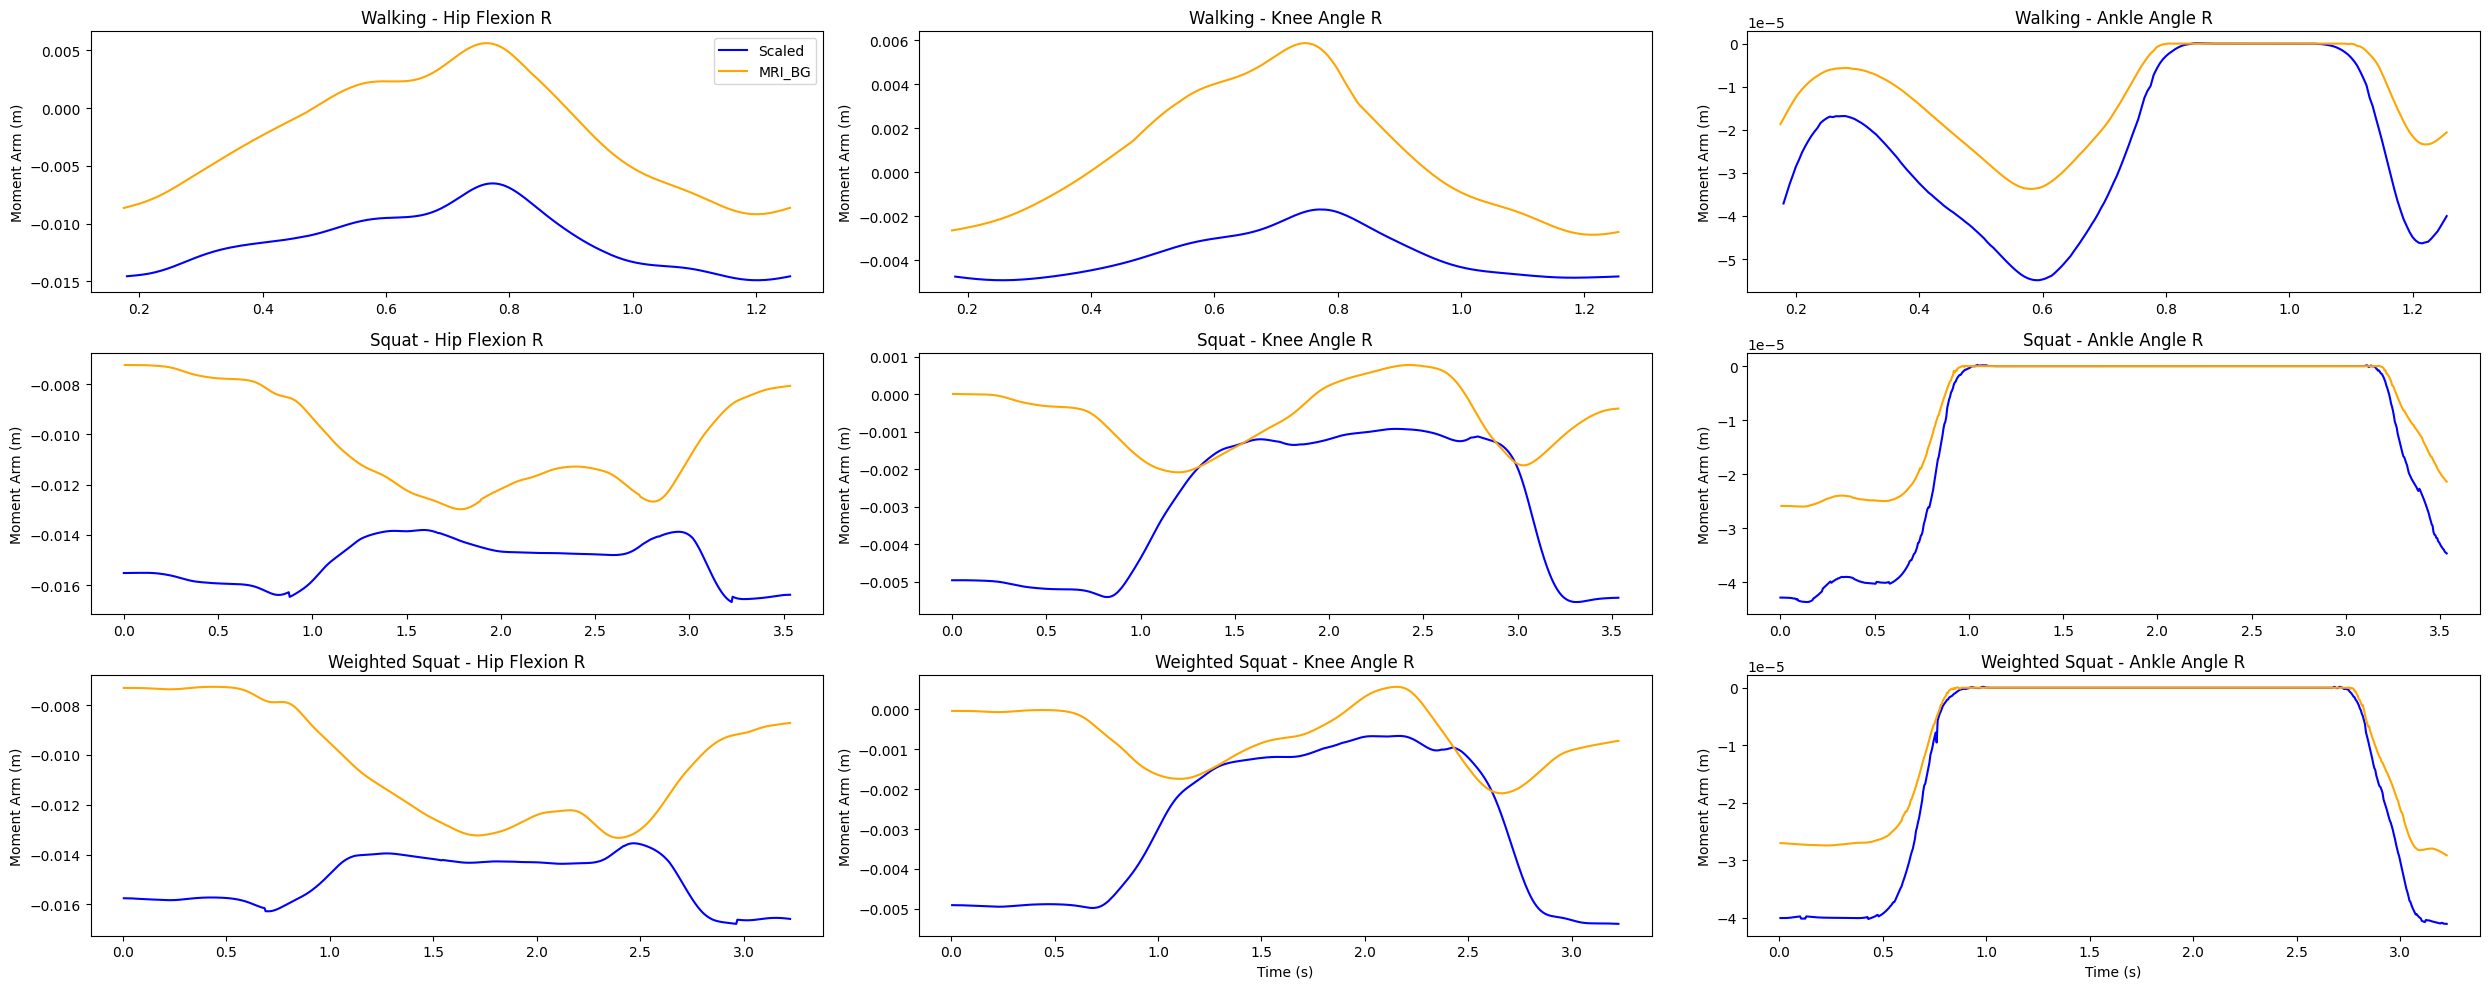

In [35]:

fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(25, 10))

walking_scaled_results = utils.load_any_data_file(os.path.join(walking_scaled.path, walking_scaled.ma, '_MuscleAnalysis_MomentArm_hip_flexion_r.sto'))
walking_MRI_results = utils.load_any_data_file(os.path.join(walking_MRI.path, walking_MRI.ma, '_MuscleAnalysis_MomentArm_hip_flexion_r.sto'))

squat_scaled_results = utils.load_any_data_file(os.path.join(squat_scaled.path, squat_scaled.ma, '_MuscleAnalysis_MomentArm_hip_flexion_r.sto'))
squat_MRI_results = utils.load_any_data_file(os.path.join(squat_MRI.path, squat_MRI.ma, '_MuscleAnalysis_MomentArm_hip_flexion_r.sto')) 

weighted_squat_scaled_results = utils.load_any_data_file(os.path.join(weighted_squat_scaled.path, weighted_squat_scaled.ma, '_MuscleAnalysis_MomentArm_hip_flexion_r.sto'))
weighted_squat_MRI_results = utils.load_any_data_file(os.path.join(weighted_squat_MRI.path, weighted_squat_MRI.ma, '_MuscleAnalysis_MomentArm_hip_flexion_r.sto'))

hip_muscles = 'addbrev_r addlong_r addmagDist_r addmagIsch_r addmagMid_r addmagProx_r bflh_r gaslat_r gasmed_r glmax1_r glmax2_r glmax3_r glmed1_r glmed2_r glmed3_r glmin1_r glmin2_r glmin3_r grac_r iliacus_r piri_r psoas_r recfem_r sart_r semimem_r semiten_r tfl_r'.split()
knee_muscles = 'bflh_r bfsh_r gaslat_r gasmed_r grac_r recfem_r sart_r semimem_r semiten_r tfl_r vasint_r vaslat_r vasmed_r'.split()
ankle_muscles = 'edl_r ehl_r fdl_r fhl_r gaslat_r gasmed_r perbrev_r perlong_r soleus_r tibant_r tibpost_r'.split()

# walking row
ax[0, 0].plot(walking_scaled_results['time'], walking_scaled_results[hip_muscles].mean(axis=1), label='Scaled', color=colors['scaled'])
ax[0, 0].plot(walking_MRI_results['time'], walking_MRI_results[hip_muscles].mean(axis=1), label='MRI_BG', color=colors['MRI_BG'])  
ax[0, 0].set_title('Walking - Hip Flexion R')
ax[0, 0].set_ylabel('Moment Arm (m)')
ax[0, 0].legend()

ax[0, 1].plot(walking_scaled_results['time'], walking_scaled_results[knee_muscles].mean(axis=1), label='Scaled', color=colors['scaled'])
ax[0, 1].plot(walking_MRI_results['time'], walking_MRI_results[knee_muscles].mean(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[0, 1].set_title('Walking - Knee Angle R')
ax[0, 1].set_ylabel('Moment Arm (m)')

ax[0, 2].plot(walking_scaled_results['time'], walking_scaled_results[ankle_muscles].mean(axis=1), label='Scaled', color=colors['scaled'])
ax[0, 2].plot(walking_MRI_results['time'], walking_MRI_results[ankle_muscles].mean(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[0, 2].set_title('Walking - Ankle Angle R')
ax[0, 2].set_ylabel('Moment Arm (m)')

# squat row
ax[1, 0].plot(squat_scaled_results['time'], squat_scaled_results[hip_muscles].mean(axis=1), label='Scaled', color=colors['scaled'])
ax[1, 0].plot(squat_MRI_results['time'], squat_MRI_results[hip_muscles].mean(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 0].set_title('Squat - Hip Flexion R')
ax[1, 0].set_ylabel('Moment Arm (m)')

ax[1, 1].plot(squat_scaled_results['time'], squat_scaled_results[knee_muscles].mean(axis=1), label='Scaled', color=colors['scaled'])
ax[1, 1].plot(squat_MRI_results['time'], squat_MRI_results[knee_muscles].mean(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 1].set_title('Squat - Knee Angle R')
ax[1, 1].set_ylabel('Moment Arm (m)')

ax[1, 2].plot(squat_scaled_results['time'], squat_scaled_results[ankle_muscles].mean(axis=1), label='Scaled', color=colors['scaled'])
ax[1, 2].plot(squat_MRI_results['time'], squat_MRI_results[ankle_muscles].mean(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 2].set_title('Squat - Ankle Angle R')
ax[1, 2].set_ylabel('Moment Arm (m)')

# weighted squat row
ax[2, 0].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results[hip_muscles].mean(axis=1), label='Scaled', color=colors['scaled'])
ax[2, 0].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results[hip_muscles].mean(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 0].set_title('Weighted Squat - Hip Flexion R')
ax[2, 0].set_ylabel('Moment Arm (m)')
 
    
ax[2, 1].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results[knee_muscles].mean(axis=1), label='Scaled', color=colors['scaled'])
ax[2, 1].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results[knee_muscles].mean(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 1].set_title('Weighted Squat - Knee Angle R')
ax[2, 1].set_ylabel('Moment Arm (m)')
ax[2, 1].set_xlabel('Time (s)')

ax[2, 2].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results[ankle_muscles].mean(axis=1), label='Scaled', color=colors['scaled'])
ax[2, 2].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results[ankle_muscles].mean(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 2].set_title('Weighted Squat - Ankle Angle R')
ax[2, 2].set_ylabel('Moment Arm (m)')
ax[2, 2].set_xlabel('Time (s)')


save_path = os.path.join(results_dir, f'ma_comparison_all_trials.png')
plt.tight_layout()

plt.savefig(save_path)
print(f"MA comparison plot saved: {save_path}")




## Muscle forces

SO comparison plot saved: c:\Git\1_current_projects\powerlifing_model\results\Compare_models\so_comparison_all_trials.png


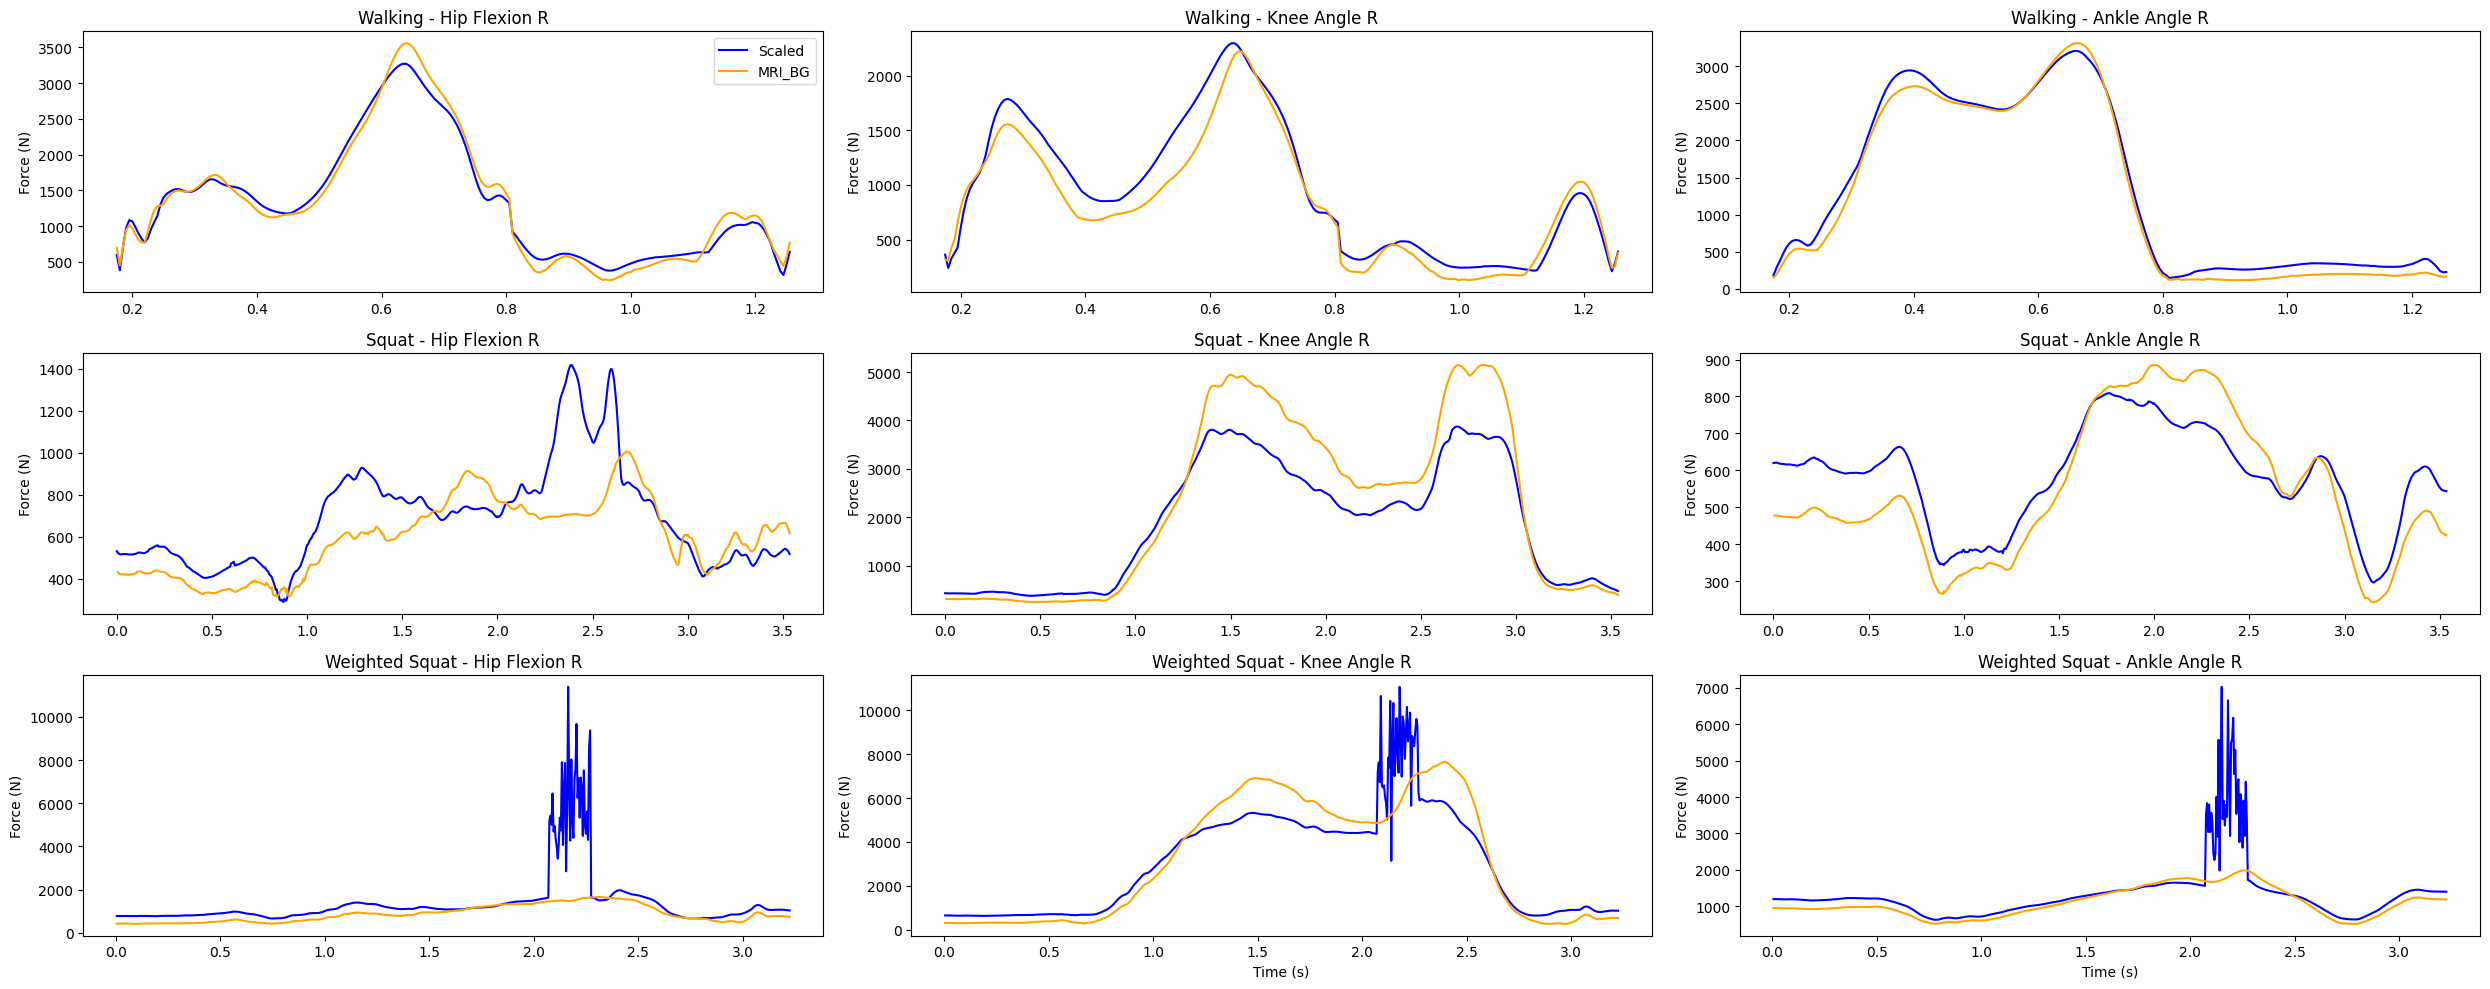

In [51]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(25, 10))

walking_scaled_results = utils.load_any_data_file(os.path.join(walking_scaled.path, walking_scaled.so_forces))
walking_MRI_results = utils.load_any_data_file(os.path.join(walking_MRI.path, walking_MRI.so_forces))

squat_scaled_results = utils.load_any_data_file(os.path.join(squat_scaled.path, squat_scaled.so_forces))
squat_MRI_results = utils.load_any_data_file(os.path.join(squat_MRI.path, squat_MRI.so_forces)) 

weighted_squat_scaled_results = utils.load_any_data_file(os.path.join(weighted_squat_scaled.path, weighted_squat_scaled.so_forces))
weighted_squat_MRI_results = utils.load_any_data_file(os.path.join(weighted_squat_MRI.path, weighted_squat_MRI.so_forces))

hip_muscles = 'addbrev_r addlong_r addmagDist_r addmagIsch_r addmagMid_r addmagProx_r bflh_r gaslat_r gasmed_r glmax1_r glmax2_r glmax3_r glmed1_r glmed2_r glmed3_r glmin1_r glmin2_r glmin3_r grac_r iliacus_r piri_r psoas_r recfem_r sart_r semimem_r semiten_r tfl_r'.split()
knee_muscles = 'bflh_r bfsh_r gaslat_r gasmed_r grac_r recfem_r sart_r semimem_r semiten_r tfl_r vasint_r vaslat_r vasmed_r'.split()
ankle_muscles = 'edl_r ehl_r fdl_r fhl_r gaslat_r gasmed_r perbrev_r perlong_r soleus_r tibant_r tibpost_r'.split()

# walking row
ax[0, 0].plot(walking_scaled_results['time'], walking_scaled_results[hip_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[0, 0].plot(walking_MRI_results['time'], walking_MRI_results[hip_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])  
ax[0, 0].set_title('Walking - Hip Flexion R')
ax[0, 0].set_ylabel('Force (N)')
ax[0, 0].legend()

ax[0, 1].plot(walking_scaled_results['time'], walking_scaled_results[knee_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[0, 1].plot(walking_MRI_results['time'], walking_MRI_results[knee_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[0, 1].set_title('Walking - Knee Angle R')
ax[0, 1].set_ylabel('Force (N)')

ax[0, 2].plot(walking_scaled_results['time'], walking_scaled_results[ankle_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[0, 2].plot(walking_MRI_results['time'], walking_MRI_results[ankle_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[0, 2].set_title('Walking - Ankle Angle R')
ax[0, 2].set_ylabel('Force (N)')

# squat row
ax[1, 0].plot(squat_scaled_results['time'], squat_scaled_results[hip_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[1, 0].plot(squat_MRI_results['time'], squat_MRI_results[hip_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 0].set_title('Squat - Hip Flexion R')
ax[1, 0].set_ylabel('Force (N)')

ax[1, 1].plot(squat_scaled_results['time'], squat_scaled_results[knee_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[1, 1].plot(squat_MRI_results['time'], squat_MRI_results[knee_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 1].set_title('Squat - Knee Angle R')
ax[1, 1].set_ylabel('Force (N)')

ax[1, 2].plot(squat_scaled_results['time'], squat_scaled_results[ankle_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[1, 2].plot(squat_MRI_results['time'], squat_MRI_results[ankle_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 2].set_title('Squat - Ankle Angle R')
ax[1, 2].set_ylabel('Force (N)')

# weighted squat row
ax[2, 0].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results[hip_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[2, 0].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results[hip_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 0].set_title('Weighted Squat - Hip Flexion R')
ax[2, 0].set_ylabel('Force (N)')


ax[2, 1].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results[knee_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[2, 1].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results[knee_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 1].set_title('Weighted Squat - Knee Angle R')
ax[2, 1].set_ylabel('Force (N)')
ax[2, 1].set_xlabel('Time (s)')

ax[2, 2].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results[ankle_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[2, 2].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results[ankle_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 2].set_title('Weighted Squat - Ankle Angle R')
ax[2, 2].set_ylabel('Force (N)')
ax[2, 2].set_xlabel('Time (s)')


save_path = os.path.join(results_dir, f'so_comparison_all_trials.png')
plt.tight_layout()

plt.savefig(save_path)
print(f"SO comparison plot saved: {save_path}")



## Muscle forces CEINMS

CEINMS comparison plot saved: c:\Git\1_current_projects\powerlifing_model\results\Compare_models\ceinms_comparison_all_trials.png


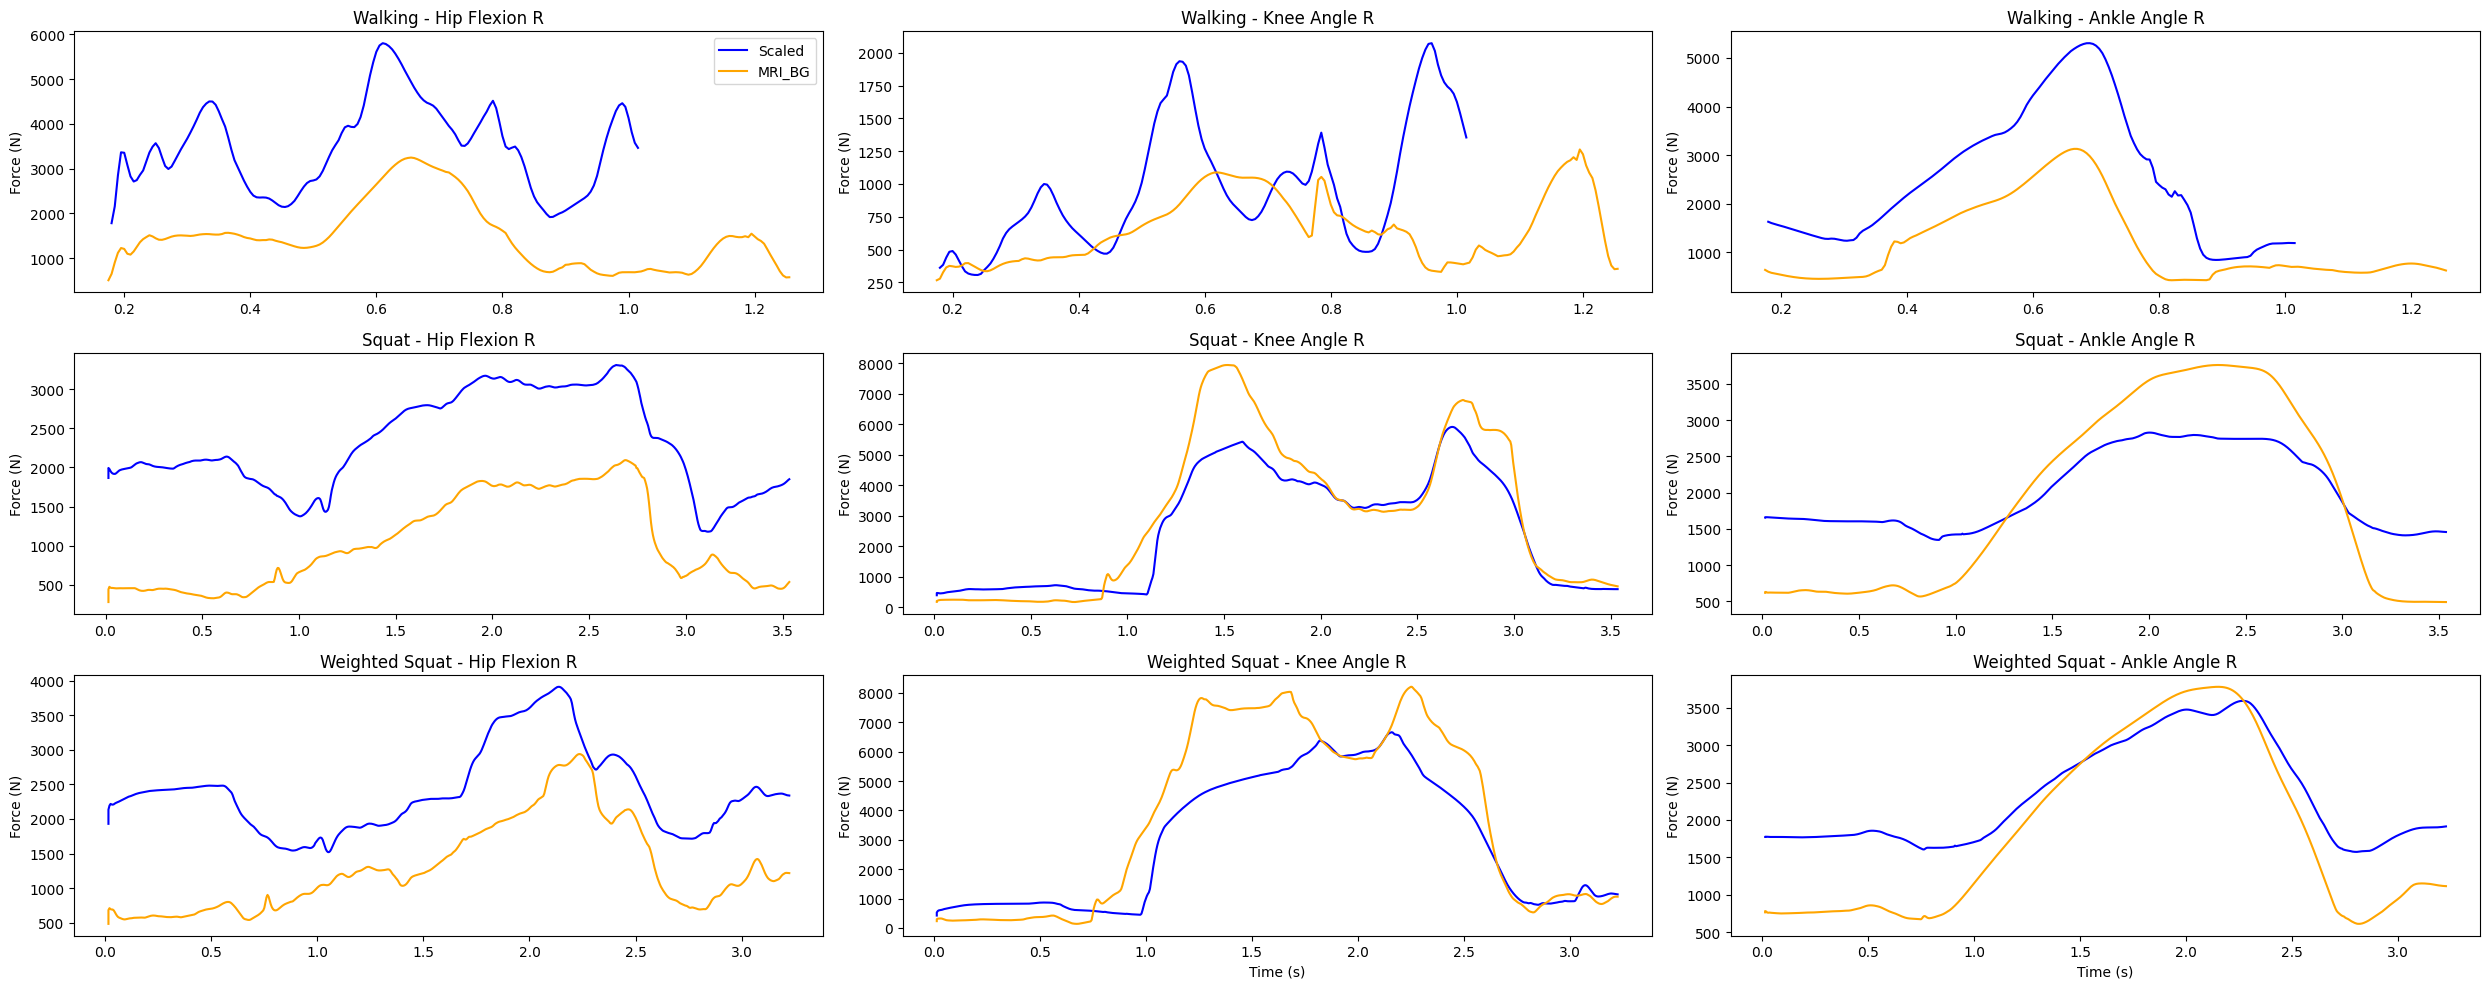

In [50]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(25, 10))

walking_scaled_results = utils.load_any_data_file(os.path.join(walking_scaled.path, walking_scaled.jra_forces_ceinms))
walking_MRI_results = utils.load_any_data_file(os.path.join(walking_MRI.path, walking_MRI.jra_forces_ceinms))

squat_scaled_results = utils.load_any_data_file(os.path.join(squat_scaled.path, squat_scaled.jra_forces_ceinms))
squat_MRI_results = utils.load_any_data_file(os.path.join(squat_MRI.path, squat_MRI.jra_forces_ceinms)) 

weighted_squat_scaled_results = utils.load_any_data_file(os.path.join(weighted_squat_scaled.path, weighted_squat_scaled.jra_forces_ceinms))
weighted_squat_MRI_results = utils.load_any_data_file(os.path.join(weighted_squat_MRI.path, weighted_squat_MRI.jra_forces_ceinms))

hip_muscles = 'addbrev_r addlong_r addmagDist_r addmagIsch_r addmagMid_r addmagProx_r bflh_r gaslat_r gasmed_r glmax1_r glmax2_r glmax3_r glmed1_r glmed2_r glmed3_r glmin1_r glmin2_r glmin3_r grac_r iliacus_r piri_r psoas_r recfem_r sart_r semimem_r semiten_r tfl_r'.split()
knee_muscles = 'bflh_r bfsh_r gaslat_r gasmed_r grac_r recfem_r sart_r semimem_r semiten_r tfl_r vasint_r vaslat_r vasmed_r'.split()
ankle_muscles = 'edl_r ehl_r fdl_r fhl_r gaslat_r gasmed_r perbrev_r perlong_r soleus_r tibant_r tibpost_r'.split()

# walking row
ax[0, 0].plot(walking_scaled_results['time'], walking_scaled_results[hip_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[0, 0].plot(walking_MRI_results['time'], walking_MRI_results[hip_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])  
ax[0, 0].set_title('Walking - Hip Flexion R')
ax[0, 0].set_ylabel('Force (N)')
ax[0, 0].legend()

ax[0, 1].plot(walking_scaled_results['time'], walking_scaled_results[knee_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[0, 1].plot(walking_MRI_results['time'], walking_MRI_results[knee_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[0, 1].set_title('Walking - Knee Angle R')
ax[0, 1].set_ylabel('Force (N)')

ax[0, 2].plot(walking_scaled_results['time'], walking_scaled_results[ankle_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[0, 2].plot(walking_MRI_results['time'], walking_MRI_results[ankle_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[0, 2].set_title('Walking - Ankle Angle R')
ax[0, 2].set_ylabel('Force (N)')

# squat row
ax[1, 0].plot(squat_scaled_results['time'], squat_scaled_results[hip_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[1, 0].plot(squat_MRI_results['time'], squat_MRI_results[hip_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 0].set_title('Squat - Hip Flexion R')
ax[1, 0].set_ylabel('Force (N)')

ax[1, 1].plot(squat_scaled_results['time'], squat_scaled_results[knee_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[1, 1].plot(squat_MRI_results['time'], squat_MRI_results[knee_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 1].set_title('Squat - Knee Angle R')
ax[1, 1].set_ylabel('Force (N)')

ax[1, 2].plot(squat_scaled_results['time'], squat_scaled_results[ankle_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[1, 2].plot(squat_MRI_results['time'], squat_MRI_results[ankle_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 2].set_title('Squat - Ankle Angle R')
ax[1, 2].set_ylabel('Force (N)')

# weighted squat row
ax[2, 0].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results[hip_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[2, 0].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results[hip_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 0].set_title('Weighted Squat - Hip Flexion R')
ax[2, 0].set_ylabel('Force (N)')
    
ax[2, 1].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results[knee_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[2, 1].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results[knee_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 1].set_title('Weighted Squat - Knee Angle R')
ax[2, 1].set_ylabel('Force (N)')
ax[2, 1].set_xlabel('Time (s)')

ax[2, 2].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results[ankle_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[2, 2].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results[ankle_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 2].set_title('Weighted Squat - Ankle Angle R')
ax[2, 2].set_ylabel('Force (N)')
ax[2, 2].set_xlabel('Time (s)')


save_path = os.path.join(results_dir, f'ceinms_comparison_all_trials.png')
plt.tight_layout()

plt.savefig(save_path)
print(f"CEINMS comparison plot saved: {save_path}")


## JRF SO

JRA comparison plot saved: c:\Git\1_current_projects\powerlifing_model\results\Compare_models\jra_comparison_all_trials.png


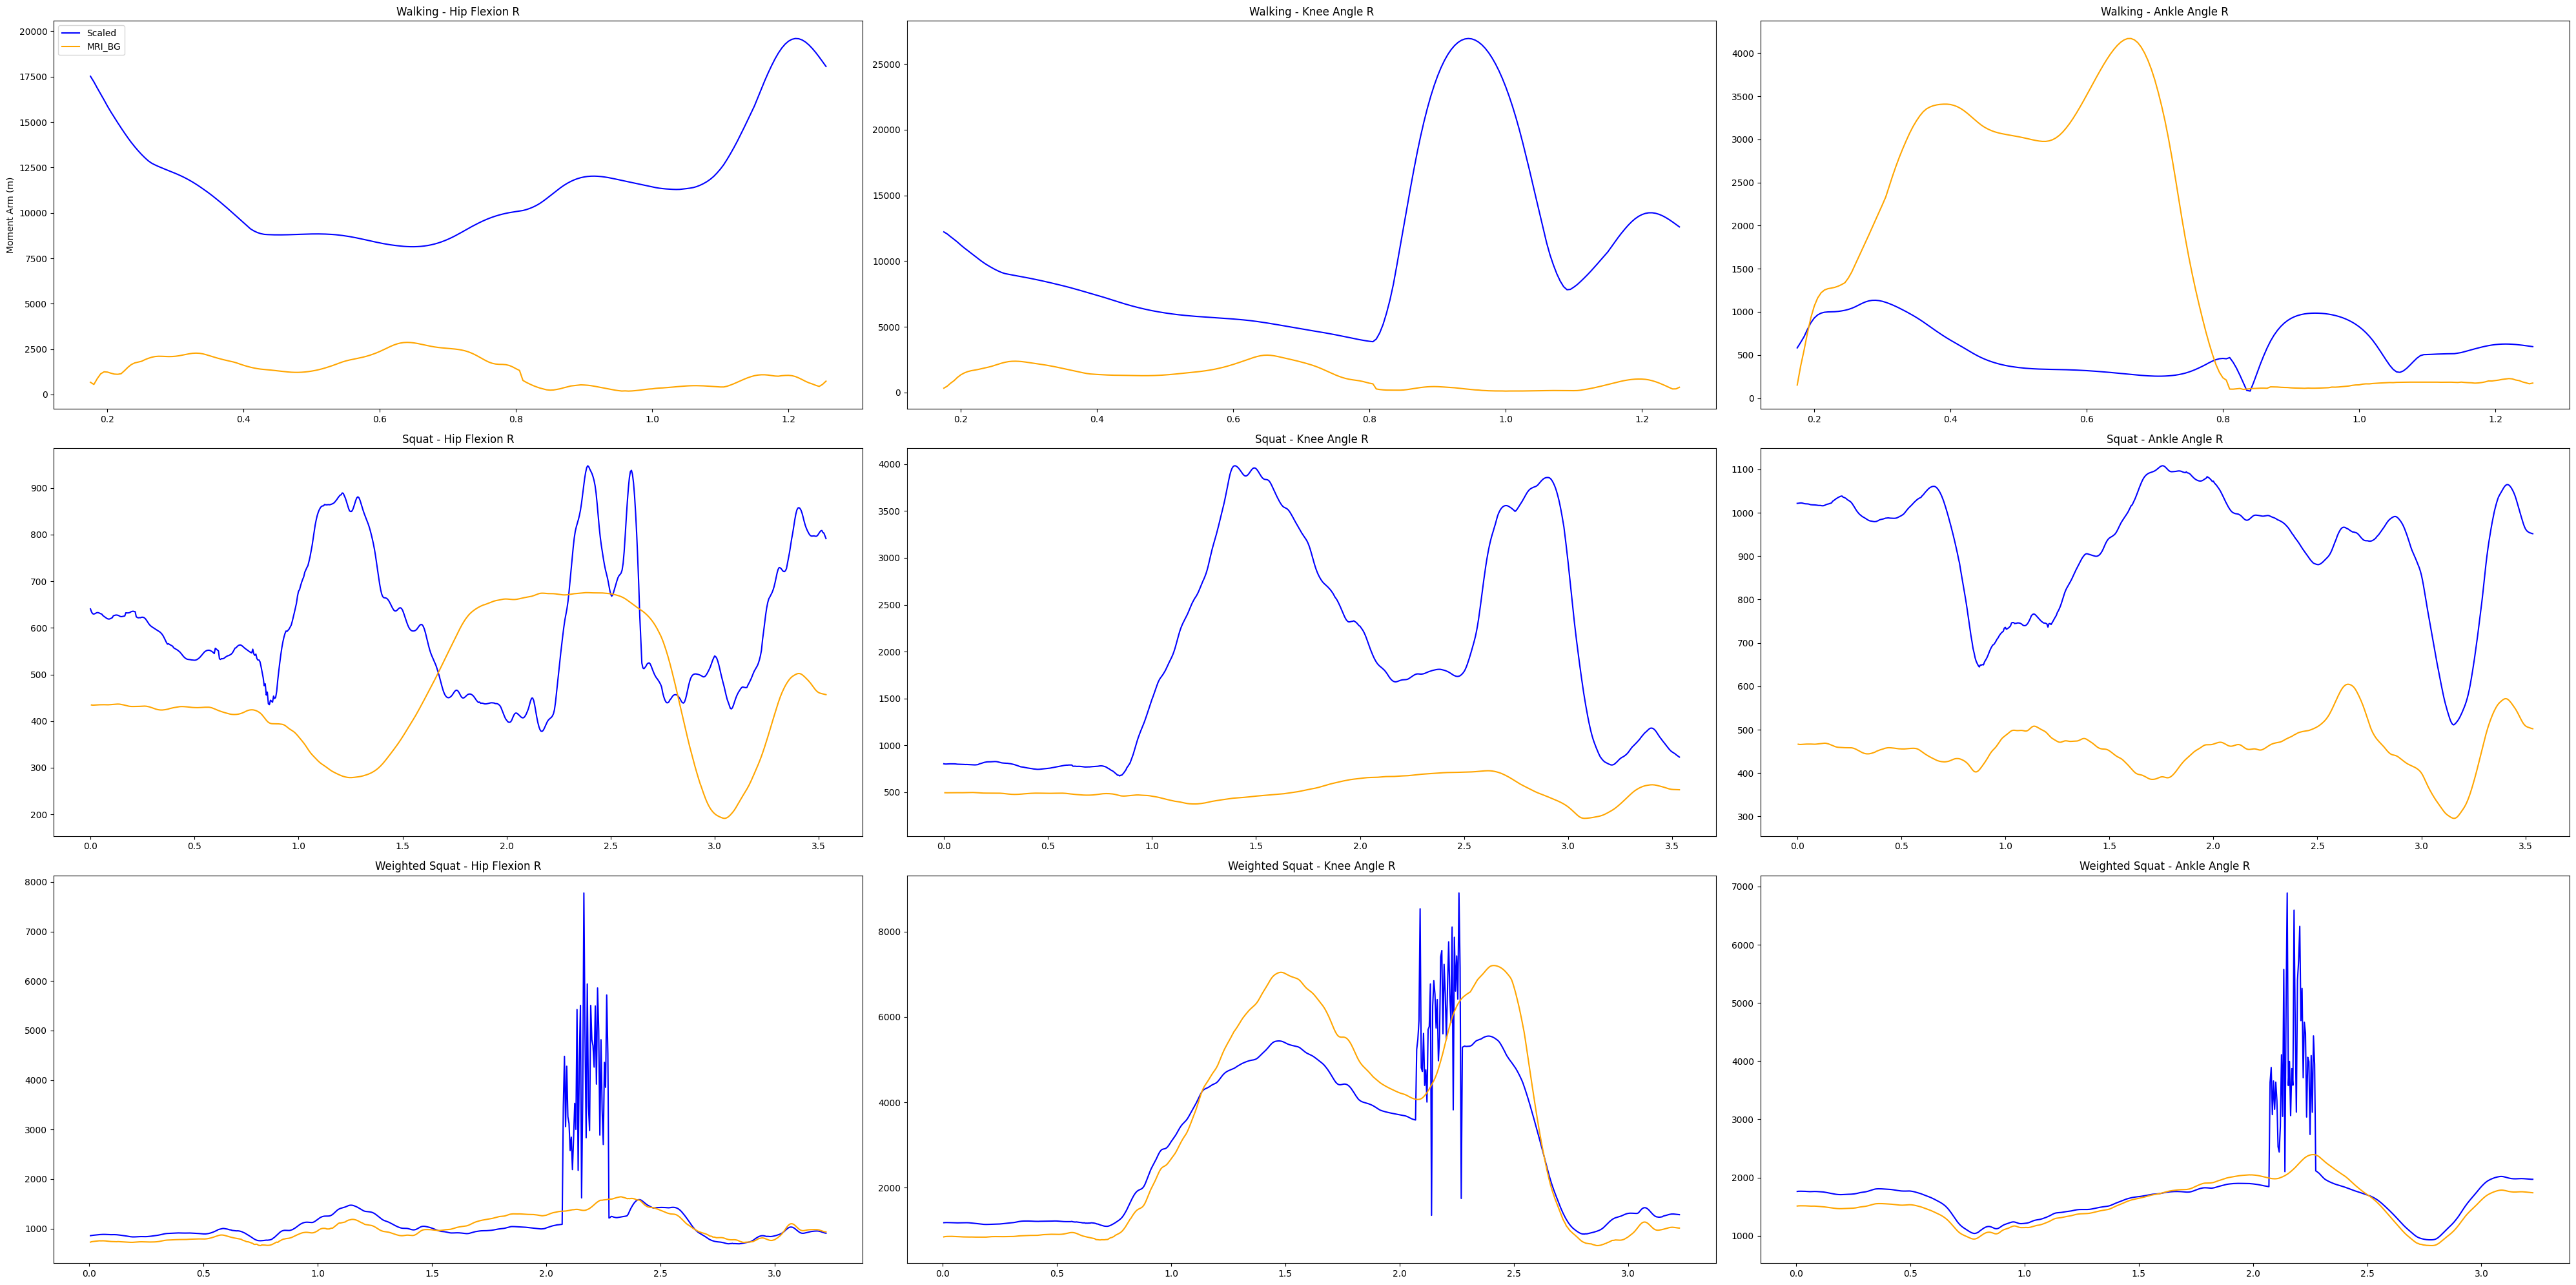

In [49]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(40, 20))

walking_scaled_results = utils.load_any_data_file(os.path.join(walking_scaled.path, walking_scaled.jra))
walking_MRI_results = utils.load_any_data_file(os.path.join(walking_MRI.path, walking_MRI.jra))

squat_scaled_results = utils.load_any_data_file(os.path.join(squat_scaled.path, squat_scaled.jra))
squat_MRI_results = utils.load_any_data_file(os.path.join(squat_MRI.path, squat_MRI.jra)) 

weighted_squat_scaled_results = utils.load_any_data_file(os.path.join(weighted_squat_scaled.path, weighted_squat_scaled.jra))
weighted_squat_MRI_results = utils.load_any_data_file(os.path.join(weighted_squat_MRI.path, weighted_squat_MRI.jra))

def sum3d(df, columns):
    x = df[columns[0]]
    y = df[columns[1]]
    z = df[columns[2]]
    sum = np.sqrt(x**2 +  y**2 + z**2)
    return sum

hip = ['hip_r_on_femur_r_in_femur_r_fx', 'hip_r_on_femur_r_in_femur_r_fy', 'hip_r_on_femur_r_in_femur_r_fz']
knee = ['walker_knee_r_on_tibia_r_in_tibia_r_fx', 'walker_knee_r_on_tibia_r_in_tibia_r_fy', 'walker_knee_r_on_tibia_r_in_tibia_r_fz']
ankle = ['ankle_r_on_talus_r_in_talus_r_fx', 'ankle_r_on_talus_r_in_talus_r_fy', 'ankle_r_on_talus_r_in_talus_r_fz']

# walking row
ax[0, 0].plot(walking_scaled_results['time'], sum3d(walking_scaled_results, hip), label='Scaled', color=colors['scaled'])
ax[0, 0].plot(walking_MRI_results['time'], sum3d(walking_MRI_results, hip), label='MRI_BG', color=colors['MRI_BG'])  
ax[0, 0].set_title('Walking - Hip Flexion R')
ax[0, 0].set_ylabel('Moment Arm (m)')
ax[0, 0].legend()

ax[0, 1].plot(walking_scaled_results['time'], sum3d(walking_scaled_results, knee), label='Scaled', color=colors['scaled'])
ax[0, 1].plot(walking_MRI_results['time'], sum3d(walking_MRI_results, knee), label='MRI_BG', color=colors['MRI_BG'])
ax[0, 1].set_title('Walking - Knee Angle R')

ax[0, 2].plot(walking_scaled_results['time'], sum3d(walking_scaled_results, ankle), label='Scaled', color=colors['scaled'])
ax[0, 2].plot(walking_MRI_results['time'], sum3d(walking_MRI_results, ankle), label='MRI_BG', color=colors['MRI_BG'])
ax[0, 2].set_title('Walking - Ankle Angle R')

# squat row
ax[1, 0].plot(squat_scaled_results['time'], sum3d(squat_scaled_results, hip), label='Scaled', color=colors['scaled'])
ax[1, 0].plot(squat_MRI_results['time'], sum3d(squat_MRI_results, hip), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 0].set_title('Squat - Hip Flexion R')

ax[1, 1].plot(squat_scaled_results['time'], sum3d(squat_scaled_results, knee), label='Scaled', color=colors['scaled'])
ax[1, 1].plot(squat_MRI_results['time'], sum3d(squat_MRI_results, knee), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 1].set_title('Squat - Knee Angle R')

ax[1, 2].plot(squat_scaled_results['time'], sum3d(squat_scaled_results, ankle), label='Scaled', color=colors['scaled'])
ax[1, 2].plot(squat_MRI_results['time'], sum3d(squat_MRI_results, ankle), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 2].set_title('Squat - Ankle Angle R')

# weighted squat row
ax[2, 0].plot(weighted_squat_scaled_results['time'], sum3d(weighted_squat_scaled_results, hip), label='Scaled', color=colors['scaled'])
ax[2, 0].plot(weighted_squat_MRI_results['time'], sum3d(weighted_squat_MRI_results, hip), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 0].set_title('Weighted Squat - Hip Flexion R')

ax[2, 1].plot(weighted_squat_scaled_results['time'], sum3d(weighted_squat_scaled_results, knee), label='Scaled', color=colors['scaled'])
ax[2, 1].plot(weighted_squat_MRI_results['time'], sum3d(weighted_squat_MRI_results, knee), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 1].set_title('Weighted Squat - Knee Angle R')


ax[2, 2].plot(weighted_squat_scaled_results['time'], sum3d(weighted_squat_scaled_results, ankle), label='Scaled', color=colors['scaled'])
ax[2, 2].plot(weighted_squat_MRI_results['time'], sum3d(weighted_squat_MRI_results, ankle), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 2].set_title('Weighted Squat - Ankle Angle R')


save_path = os.path.join(results_dir, f'jra_comparison_all_trials.png')
plt.tight_layout()

plt.savefig(save_path)
print(f"JRA comparison plot saved: {save_path}")



## JRA ceinms

JRA CEINMS comparison plot saved: c:\Git\1_current_projects\powerlifing_model\results\Compare_models\jraCEINMS_comparison_all_trials.png


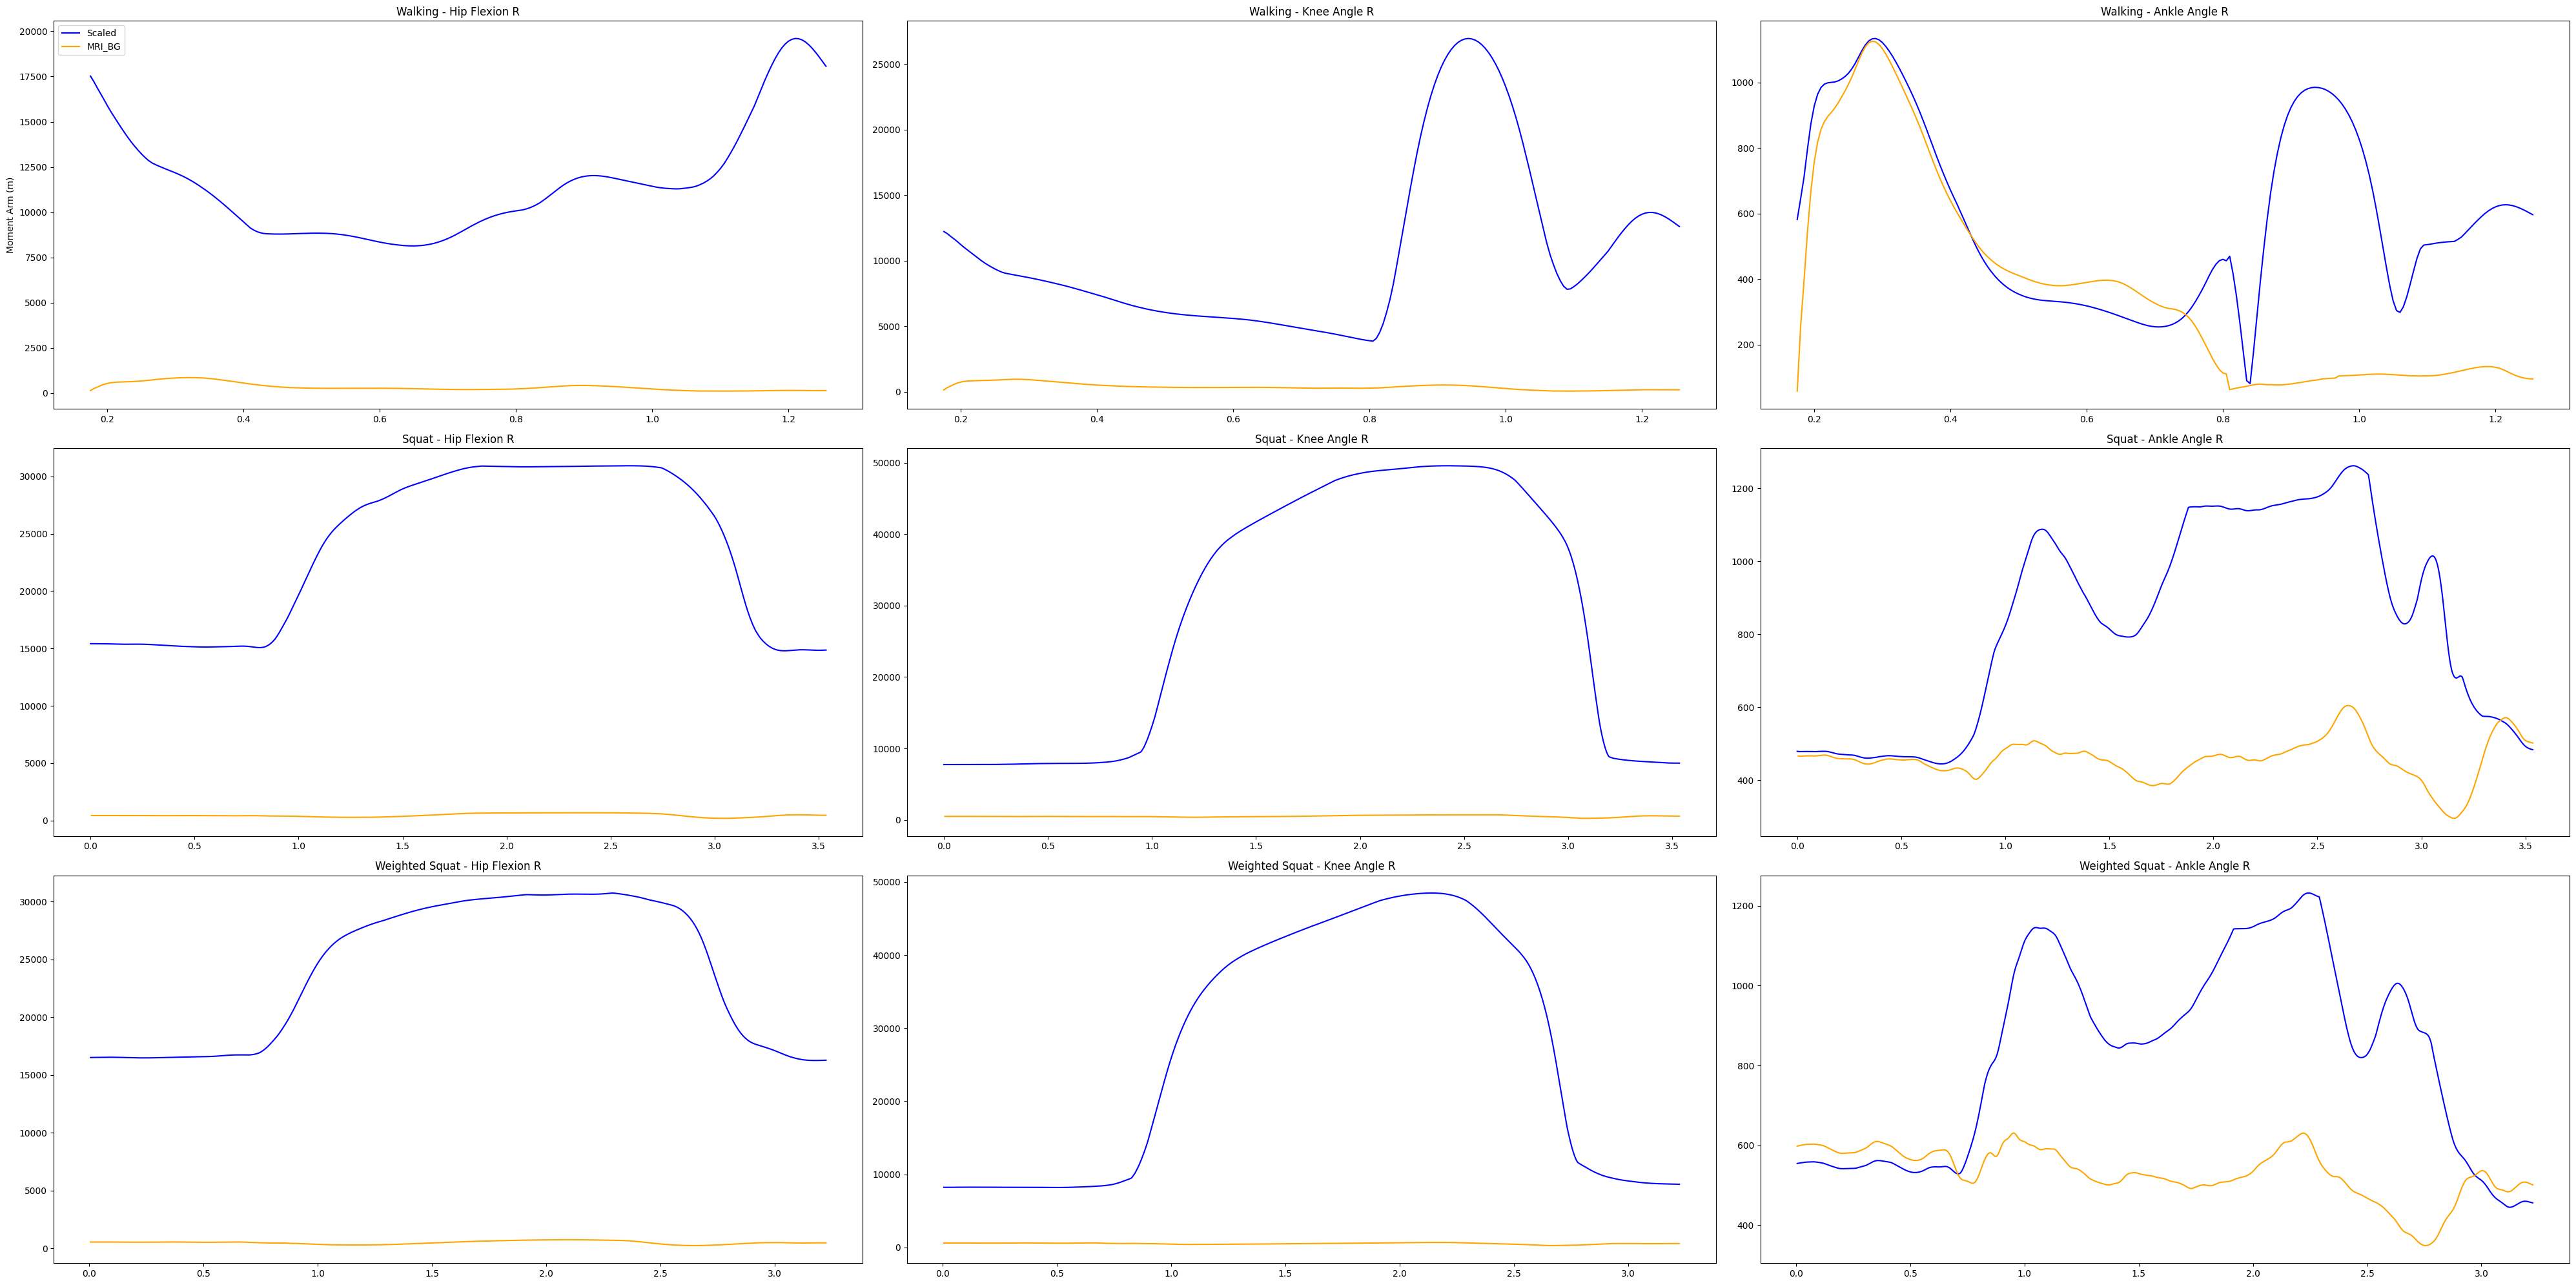

In [48]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(40, 20))

walking_scaled_results = utils.load_any_data_file(os.path.join(walking_scaled.path, walking_scaled.jra_ceinms))
walking_MRI_results = utils.load_any_data_file(os.path.join(walking_MRI.path, walking_MRI.jra_ceinms))

squat_scaled_results = utils.load_any_data_file(os.path.join(squat_scaled.path, squat_scaled.jra_ceinms))
squat_MRI_results = utils.load_any_data_file(os.path.join(squat_MRI.path, squat_MRI.jra_ceinms)) 

weighted_squat_scaled_results = utils.load_any_data_file(os.path.join(weighted_squat_scaled.path, weighted_squat_scaled.jra_ceinms))
weighted_squat_MRI_results = utils.load_any_data_file(os.path.join(weighted_squat_MRI.path, weighted_squat_MRI.jra_ceinms))

def sum3d(df, columns):
    x = df[columns[0]]
    y = df[columns[1]]
    z = df[columns[2]]
    sum = np.sqrt(x**2 +  y**2 + z**2)
    return sum

hip = ['hip_r_on_femur_r_in_femur_r_fx', 'hip_r_on_femur_r_in_femur_r_fy', 'hip_r_on_femur_r_in_femur_r_fz']
knee = ['walker_knee_r_on_tibia_r_in_tibia_r_fx', 'walker_knee_r_on_tibia_r_in_tibia_r_fy', 'walker_knee_r_on_tibia_r_in_tibia_r_fz']
ankle = ['ankle_r_on_talus_r_in_talus_r_fx', 'ankle_r_on_talus_r_in_talus_r_fy', 'ankle_r_on_talus_r_in_talus_r_fz']

# walking row
ax[0, 0].plot(walking_scaled_results['time'], sum3d(walking_scaled_results, hip), label='Scaled', color=colors['scaled'])
ax[0, 0].plot(walking_MRI_results['time'], sum3d(walking_MRI_results, hip), label='MRI_BG', color=colors['MRI_BG'])  
ax[0, 0].set_title('Walking - Hip Flexion R')
ax[0, 0].set_ylabel('Moment Arm (m)')
ax[0, 0].legend()

ax[0, 1].plot(walking_scaled_results['time'], sum3d(walking_scaled_results, knee), label='Scaled', color=colors['scaled'])
ax[0, 1].plot(walking_MRI_results['time'], sum3d(walking_MRI_results, knee), label='MRI_BG', color=colors['MRI_BG'])
ax[0, 1].set_title('Walking - Knee Angle R')

ax[0, 2].plot(walking_scaled_results['time'], sum3d(walking_scaled_results, ankle), label='Scaled', color=colors['scaled'])
ax[0, 2].plot(walking_MRI_results['time'], sum3d(walking_MRI_results, ankle), label='MRI_BG', color=colors['MRI_BG'])
ax[0, 2].set_title('Walking - Ankle Angle R')

# squat row
ax[1, 0].plot(squat_scaled_results['time'], sum3d(squat_scaled_results, hip), label='Scaled', color=colors['scaled'])
ax[1, 0].plot(squat_MRI_results['time'], sum3d(squat_MRI_results, hip), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 0].set_title('Squat - Hip Flexion R')

ax[1, 1].plot(squat_scaled_results['time'], sum3d(squat_scaled_results, knee), label='Scaled', color=colors['scaled'])
ax[1, 1].plot(squat_MRI_results['time'], sum3d(squat_MRI_results, knee), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 1].set_title('Squat - Knee Angle R')

ax[1, 2].plot(squat_scaled_results['time'], sum3d(squat_scaled_results, ankle), label='Scaled', color=colors['scaled'])
ax[1, 2].plot(squat_MRI_results['time'], sum3d(squat_MRI_results, ankle), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 2].set_title('Squat - Ankle Angle R')

# weighted squat row
ax[2, 0].plot(weighted_squat_scaled_results['time'], sum3d(weighted_squat_scaled_results, hip), label='Scaled', color=colors['scaled'])
ax[2, 0].plot(weighted_squat_MRI_results['time'], sum3d(weighted_squat_MRI_results, hip), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 0].set_title('Weighted Squat - Hip Flexion R')

ax[2, 1].plot(weighted_squat_scaled_results['time'], sum3d(weighted_squat_scaled_results, knee), label='Scaled', color=colors['scaled'])
ax[2, 1].plot(weighted_squat_MRI_results['time'], sum3d(weighted_squat_MRI_results, knee), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 1].set_title('Weighted Squat - Knee Angle R')


ax[2, 2].plot(weighted_squat_scaled_results['time'], sum3d(weighted_squat_scaled_results, ankle), label='Scaled', color=colors['scaled'])
ax[2, 2].plot(weighted_squat_MRI_results['time'], sum3d(weighted_squat_MRI_results, ankle), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 2].set_title('Weighted Squat - Ankle Angle R')


save_path = os.path.join(results_dir, f'jraCEINMS_comparison_all_trials.png')
plt.tight_layout()

plt.savefig(save_path)
print(f"JRA CEINMS comparison plot saved: {save_path}")
